# 代码流程与结果解释说明

本文档用于说明本项目当前优化分支中的代码结构、运行方式、主要脚本逻辑、输出文件含义，以及最终结果应该如何解释。它不是模型原理入门说明书，而是帮助读者把“代码做了什么”和“结果说明了什么”对应起来。


## 1. 运行环境与一键入口

本项目要求使用固定 Conda 环境：

```bat
E:\JetBrains\Anaconda3\envs\pytorch\python.exe
```

一键运行入口是：

```bat
E:\JetBrains\Anaconda3\envs\pytorch\python.exe run_stagewise_optimization.py
```

这个入口会完成完整流程：

1. 读取并审计已经构造好的模型面板；
2. 确认 231 个宏微观综合因子；
3. 运行参数实验；
4. 对每个季度执行移动窗口前向分步回归；
5. 计算 PROMETHEE 投资前景值；
6. 构造不同 Hybrid Score；
7. 做 Top-K 回测；
8. 生成 13 级评级；
9. 根据验证集选择最终方案；
10. 输出 CSV、JSON、图像和 Notebook 报告。

所有优化输出默认写入：

- `outputs_optimized/`
- `figures_optimized/`
- `final_stagewise_report_optimized.ipynb`


## 2. 代码文件总览

| 文件 | 作用 | 主要输出 |
|---|---|---|
| `run_stagewise_optimization.py` | 当前优化版主入口，串联完整实验、模型选择、输出和报告生成 | `outputs_optimized/`、`figures_optimized/`、`final_stagewise_report_optimized.ipynb` |
| `scripts/stagewise_utils.py` | 公共工具函数，例如 RankIC、最大回撤、绩效指标、字段识别 | 被其他脚本调用 |
| `scripts/01_build_stagewise_composite_factors.py` | 构造模型面板和 231 个综合因子 | `outputs/model_ready_stagewise_panel.parquet`、`outputs/composite_factor_list.csv` |
| `scripts/02_forward_stagewise_selection.py` | 单独运行前向分步回归变量选择 | 前向入选因子、预测面板、RankIC |
| `scripts/03_promethee_stagewise.py` | 单独运行熵权-PROMETHEE 投资前景评价 | PROMETHEE 权重和净流分数 |
| `scripts/04_backtest_rating_stagewise.py` | 单独运行 Hybrid Score、Top-K 回测和评级 | Top-K、评级结果 |
| `scripts/05_promethee_preference_sensitivity.py` | 对比不同 PROMETHEE 偏好函数 | `promethee_preference_function_comparison.csv` |
| `scripts/06_generate_additional_visualizations.py` | 生成补充可视化图像 | `figures_optimized/` 中的参数、评分方案和风险图 |

可以把 `run_stagewise_optimization.py` 理解为“总控脚本”，`scripts/` 下的编号脚本是分步骤版本和辅助分析版本。


## 3. 主入口代码逻辑

`run_stagewise_optimization.py` 中最重要的流程如下。

### 3.1 环境与目录

代码开头固定了：

- `OUT = outputs_optimized`
- `FIG = figures_optimized`
- `SRC_OUT = outputs`
- `LABEL = future_return_1q`
- `TRAIN_Q = 1–21`
- `VALID_Q = 22–25`
- `TEST_Q = 26–30`

这意味着代码不会把测试集拿来调参。训练集用于拟合和滚动训练，验证集用于选择参数，测试集只用于最终 holdout 检验。

### 3.2 数据读取与审计

`load_model_panel()` 会读取：

- `outputs/model_ready_stagewise_panel.parquet`
- `outputs/composite_factor_list.csv`

并检查：

1. 标签 `future_return_1q` 是否存在；
2. 综合因子数量是否为 231；
3. 综合因子是否都能在面板里找到；
4. 模型特征名里是否出现明显 ID 或收益类字段；
5. 每条样本属于 train、valid 还是 test。

如果缺少模型面板，脚本会尝试调用：

```bat
E:\JetBrains\Anaconda3\envs\pytorch\python.exe scripts\01_build_stagewise_composite_factors.py
```

重新构造 231 个综合因子。


## 4. 综合因子构造代码说明

`scripts/01_build_stagewise_composite_factors.py` 负责把个股因子和宏观因子组合成综合因子。

核心逻辑是：

1. 读取个股面板；
2. 读取季度宏观因子；
3. 剔除 ID、名称、收益类、标签类字段；
4. 保留审计通过的 21 个非收益型个股因子；
5. 使用 11 个可识别宏观因子；
6. 对个股因子和宏观因子做标准化；
7. 两两相乘生成：

```text
21 个个股因子 × 11 个宏观因子 = 231 个综合因子
```

综合因子的形式是：

```text
composite_个股因子_x_宏观因子
= 标准化后的个股因子 × 标准化后的宏观因子
```

这里没有把 `future_return_1q`、`月平均收益率`、区间涨跌幅、股票代码、股票名称等字段放进特征，目的是避免数据泄漏。


## 5. 前向分步回归代码说明

前向分步回归是本项目的变量选择主线。相关核心函数在 `run_stagewise_optimization.py` 中包括：

| 函数 | 作用 |
|---|---|
| `preprocess_window()` | 在滚动训练窗口内做缺失值填补、缩尾和标准化 |
| `corr_filter()` | 根据相关性阈值过滤高度重复的综合因子 |
| `choose_feature()` | 在每一步选择一个最有贡献的候选因子 |
| `run_stagewise_one_config()` | 对一个参数配置运行完整滚动前向分步回归 |
| `feature_frequency()` | 统计因子在不同季度中被选中的频率 |

每个预测季度 `q` 的做法是：

1. 只使用 `q` 之前的历史窗口；
2. 在历史窗口内从 231 个候选因子中逐步选择；
3. 每一步加入一个因子；
4. 最多选择 `max_selected_features` 个因子；
5. 用选出的因子重新拟合 OLS 或 Ridge；
6. 对第 `q` 季度股票生成 `stagewise_pred`；
7. 在季度内转成 `stagewise_rank_pct`。

当前最终配置为：

| 参数 | 最终取值 | 解释 |
|---|---|---|
| `rolling_window` | 12 | 每次使用过去 12 个季度训练 |
| `max_selected_features` | 12 | 每个窗口最多选 12 个综合因子 |
| `selection_objective` | `residual_correlation` | 优先选能解释剩余误差的因子 |
| `refit_method` | `OLS` | 入选因子后用普通最小二乘重新拟合 |
| `feature_corr_threshold` | 0.9 | 过滤高度相关因子 |
| `min_improvement` | 0.0001 | 边际提升过小则不继续加入 |
| `winsorize_quantile` | 0.05 | 做 5%/95% 缩尾 |
| `scaling_method` | `quarter_rank` | 季度内排序标准化 |

需要注意：前向分步回归虽然用 `future_return_1q` 作为训练标签，但最终不是把预测值解释成“准确收益率”，而是把预测值转成季度内排序分数，用于选股和评级。


## 6. PROMETHEE 代码说明

PROMETHEE 部分主要对应以下函数：

| 函数 | 作用 |
|---|---|
| `entropy_weights()` | 根据指标离散程度计算熵权 |
| `plus_univariate()` | 计算单指标偏好强度 |
| `promethee_flows()` | 计算每只股票的正流、负流和净流 |
| `stable_feature_pool()` | 根据入选频率和系数方向稳定性确定 PROMETHEE 指标池 |
| `build_promethee_scores()` | 生成 PROMETHEE 面板 |

PROMETHEE 的指标不是随便从 231 个因子里拿，而是来自前向分步回归筛选出的稳定因子池。这样做有两个好处：

1. PROMETHEE 和前向分步回归主线一致；
2. 避免把太多噪声因子放入多属性评价。

当前最终配置中，PROMETHEE 相关参数为：

| 参数 | 最终取值 | 解释 |
|---|---|---|
| `promethee_top_n` | 20 | 使用前向选择高频稳定因子池中的前 20 个 |
| `entropy_weight_method` | `smooth_80_20` | 熵权与等权做平滑，避免单因子权重过大 |
| `preference_function` | `linear` | 带无差异阈值的线性偏好函数 |
| `min_selected_count` | 2 | 至少在 2 个窗口中入选 |
| `sign_stability_threshold` | 0.55 | 系数方向需要有基本稳定性 |

偏好函数敏感性实验显示，PROMETHEE 本身在验证集上的 Top-K 表现并不强；最终主方案选择的是 `pure_stagewise_score`，说明本次样本中前向分步回归排序信号强于 PROMETHEE 净流分数。PROMETHEE 的主要价值体现在补充解释、多属性评价和敏感性分析，而不是替代前向分步回归主线。


## 7. Hybrid Score 代码说明

Hybrid Score 的构造函数是 `build_hybrid_panel()`。

它把两类分数统一成季度内排名分位数：

- `stagewise_rank_pct`
- `promethee_rank_pct`

然后构造五种候选评分：

| 评分名称 | 含义 |
|---|---|
| `pure_stagewise_score` | 只使用前向分步回归排序 |
| `pure_promethee_score` | 只使用 PROMETHEE 排序 |
| `hybrid_score_70_30` | 70% PROMETHEE + 30% 前向分步回归 |
| `hybrid_score_50_50` | 50% PROMETHEE + 50% 前向分步回归 |
| `hybrid_score_30_70` | 30% PROMETHEE + 70% 前向分步回归 |

最终配置选择：

```text
hybrid_score_name = pure_stagewise_score
top_k = 20
```

这说明在当前数据和验证集选择规则下，最稳妥的主方案是直接使用前向分步回归排序，而不是强行融合 PROMETHEE。文档和报告仍保留 PROMETHEE 与 Hybrid 的结果，因为它们是课程主线的一部分，也能说明多属性评价方法在本项目中的对照作用。


## 8. Top-K 回测代码说明

Top-K 回测相关函数包括：

| 函数 | 作用 |
|---|---|
| `evaluate_topk()` | 每季度按评分选出 Top-K 股票并计算持有期收益 |
| `topk_metrics()` | 汇总年化收益、波动率、Sharpe、Alpha、Beta、回撤、换手率等指标 |

Top-K 的含义是：

> 每个季度把股票按模型评分从高到低排序，选出前 K 只，等权持有到下一期。

本项目比较过 Top10、Top15、Top20、Top30、Top50，但最终主方案使用 Top20。原因是：

1. Top10 可能收益更高，但太集中；
2. Top50 更分散，但可能稀释信号；
3. Top20 在课程项目里更容易解释，也相对兼顾集中度和分散度。

如果没有外部市场指数，代码使用当期股票池等权平均收益作为 benchmark，用于计算 Alpha、Beta。


## 9. 13 级评级代码说明

评级输出由 `rating_outputs()` 生成。

做法是：

1. 每个季度内按最终分数排序；
2. 按分位数切成 13 组；
3. 最高组为 AAA，最低组为 B；
4. 评级生成时不使用 `future_return_1q`；
5. `future_return_1q` 只用于事后评价每个评级组表现。

评级列表为：

```text
AAA, AA+, AA, AA-, A+, A, A-, BBB+, BBB, BBB-, BB+, BB, B
```

评级的作用不是保证 AAA 一定比 AA 或 A 收益更高，而是把股票池分成不同投资前景层级，用于候选池筛选和解释。


## 10. 可视化代码说明

`scripts/06_generate_additional_visualizations.py` 负责生成补充图像，包括：

| 图像类型 | 代表文件 | 用途 |
|---|---|---|
| 参数对比 | `fig_parameter_stagewise_comparison_optimized.png` | 比较不同前向分步参数 |
| 预处理对比 | `fig_parameter_preprocessing_comparison_optimized.png` | 比较缩尾、标准化等设置 |
| PROMETHEE 对比 | `fig_promethee_preference_function_comparison.png` | 比较不同偏好函数 |
| 评分方案对比 | `fig_score_scheme_valid_test_bars_optimized.png` | 直观看 stagewise、PROMETHEE、Hybrid 谁更好 |
| Top-K 表现 | `fig_topk_cumulative_return_optimized.png` | 看组合累计收益 |
| 风险收益 | `fig_topk_risk_return_scatter_optimized.png` | 看收益和风险是否匹配 |
| 评级分层 | `fig_rating_return_by_grade_optimized.png` | 看 13 级评级是否有区分度 |

如果只想重新生成补充图像，可以运行：

```bat
E:\JetBrains\Anaconda3\envs\pytorch\python.exe scripts\06_generate_additional_visualizations.py
```


## 11. 输出文件怎么读

| 输出文件 | 内容 |
|---|---|
| `final_selected_algorithm_config.json` | 最终选择的参数配置 |
| `optimization_experiment_log.csv` | 所有实验方案的完整日志 |
| `final_algorithm_comparison_summary.csv` | 验证集综合评分靠前方案 |
| `stagewise_selected_features_by_quarter.csv` | 每个季度前向分步回归选中的因子 |
| `stagewise_feature_frequency.csv` | 因子入选频率和系数方向 |
| `stagewise_prediction_panel.csv` | 每只股票每季度的前向预测和排序 |
| `stagewise_quarterly_rankic.csv` | 每个季度的 RankIC |
| `entropy_weights_stagewise.csv` | PROMETHEE 指标熵权 |
| `promethee_scores_stagewise.csv` | PROMETHEE 正流、负流、净流 |
| `hybrid_scores_stagewise.csv` | 五种评分方案的股票层面分数 |
| `topk_performance_metrics_stagewise.csv` | Top-K 收益风险指标 |
| `rating_panel_stagewise.csv` | 股票季度评级面板 |
| `rating_performance_stagewise.csv` | 各评级组事后收益表现 |

其中，最适合写进报告正文的是：

- `final_selected_algorithm_config.json`
- `stagewise_model_summary.csv`
- `stagewise_feature_frequency.csv`
- `topk_performance_metrics_stagewise.csv`
- `rating_performance_stagewise.csv`

完整实验日志可以作为附录或可复现材料。


## 12. 最终参数与核心结果

最终参数来自 `outputs_optimized/final_selected_algorithm_config.json`：

| 参数 | 取值 |
|---|---|
| `experiment_id` | `sw_009` |
| `preprocessing_method` | `window_median` |
| `winsorize_quantile` | `0.05` |
| `scaling_method` | `quarter_rank` |
| `rolling_window` | `12` |
| `max_selected_features` | `12` |
| `selection_objective` | `residual_correlation` |
| `refit_method` | `OLS` |
| `feature_corr_threshold` | `0.9` |
| `min_improvement` | `0.0001` |
| `promethee_top_n` | `20` |
| `entropy_weight_method` | `smooth_80_20` |
| `preference_function` | `linear` |
| `hybrid_score_name` | `pure_stagewise_score` |
| `top_k` | `20` |

前向分步回归 RankIC 汇总：

| split | mean RankIC | Top20 平均持有期收益 |
|---|---:|---:|
| train | -0.0390 | 2.4321 |
| valid | 0.1371 | 17.1908 |
| test | 0.0649 | 0.5679 |

最终 Top20 组合绩效：

| split | 年化收益 | 年化波动 | Sharpe | Alpha | Beta | 最大回撤 | 胜率 | 平均换手率 |
|---|---:|---:|---:|---:|---:|---:|---:|---:|
| train | 8.82% | 16.75% | 0.5264 | -6.00% | 1.0438 | -5.28% | 55.56% | 78.33% |
| valid | 86.68% | 19.40% | 4.4688 | 53.48% | 0.8029 | 0.00% | 100.00% | 93.75% |
| test | 1.50% | 14.03% | 0.1068 | 0.43% | 0.8633 | -7.08% | 60.00% | 81.00% |
| all | 20.33% | 20.53% | 0.9904 | 8.34% | 1.0068 | -7.08% | 66.67% | 82.50% |

这些结果说明：

1. 验证集表现明显较强；
2. 测试集收益和 Sharpe 明显回落；
3. 测试集没有严重崩溃，但只能说明 holdout 样本中仍有弱正表现；
4. 换手率较高，真实交易中如果考虑成本，实际收益可能低于无成本回测。


## 13. 高频入选因子怎么解释

`stagewise_feature_frequency.csv` 显示，入选次数较高的因子包括：

| 因子 | 入选次数 | 平均系数方向 |
|---|---:|---:|
| `composite_净资产收益率_TTM_x_ntis` | 10 | 负向 |
| `composite_市净率PB_LF_x_svar` | 9 | 正向 |
| `composite_净资产收益率_TTM_x_itgr` | 8 | 混合偏正 |
| `composite_流通市值_x_svar` | 7 | 正向 |
| `composite_总市值_证监会算法_x_bm` | 6 | 方向不稳定 |

这些结果表示：模型在多个滚动窗口中反复选到盈利能力、估值、市值规模与宏观状态交互后的综合因子。它们不是单独说明“某个财务指标永远有效”，而是说明在不同宏观环境下，公司特征和宏观变量的交互可能对横截面排序有一定解释力。

需要谨慎的是，入选频率高不等于未来一定赚钱。它只说明这些因子在滚动训练窗口中经常被前向分步回归选中。


## 14. 为什么验证集好很多，测试集弱很多

这点很重要。验证集表现好，并不等于模型未来一定好。

本项目用验证集选择参数，所以验证集天然更接近“模型调参目标”。即使没有数据泄漏，只要参数是在验证集上选的，验证集表现通常也会比测试集更好。

测试集是最后的 holdout 检验。最终结果中：

- valid RankIC = 0.1371；
- test RankIC = 0.0649；
- valid 年化收益 = 86.68%；
- test 年化收益 = 1.50%；
- valid Sharpe = 4.4688；
- test Sharpe = 0.1068。

这说明模型在验证集上有较明显排序和组合表现，但测试集只保留了较弱的正向信号。正确解释是：

> 模型具有一定横截面排序价值，但样本外稳定性有限。

不应写成：

> 模型可以稳定预测未来收益，或者策略显著稳定盈利。


## 15. 为什么最终不是 Hybrid Score

从课程逻辑看，Hybrid Score 是主线之一；但参数选择必须服从验证集结果和稳定性约束。

本次最终配置为 `pure_stagewise_score`，说明在固定验证集选择规则下：

1. 前向分步回归排序本身已经给出了较强的验证集 Top20 表现；
2. PROMETHEE 净流作为多属性评价有解释价值，但单独用于 Top-K 收益并不强；
3. 强行把 PROMETHEE 混入最终分数，反而可能稀释前向排序信号；
4. 因此最终主方案选择 `pure_stagewise_score` 更符合“用验证集选择参数”的原则。

这并不等于 PROMETHEE 没有用。PROMETHEE 在本项目中的作用是：

- 提供多属性投资前景评价；
- 展示不同因子权重；
- 做偏好函数敏感性比较；
- 支撑课程中“投资前景评价”而不只是回归排序。


## 16. PROMETHEE 偏好函数结果怎么解释

偏好函数敏感性比较文件是：

```text
outputs_optimized/promethee_preference_function_comparison.csv
```

最终 PROMETHEE 配置采用 `linear` 偏好函数。它的意思是：

> 很小的差异不直接给满分，中等差异按比例增加，差异足够大才认为完全偏好。

这比 `usual` 普通偏好函数更适合连续型股票因子，因为普通偏好函数会把“只高 0.001”和“高 1.000”都视为完全胜出。

不过，敏感性实验也显示 PROMETHEE 各偏好函数在验证集上的 Top-K 指标整体偏弱，因此最终没有让 PROMETHEE 排序替代前向分步回归排序。


## 17. 评级结果怎么解释

评级表现来自：

```text
outputs_optimized/rating_performance_stagewise.csv
```

在测试集中，高评级组整体相对低评级组有一定优势。例如：

- AAA 到 A+ 等高评级组的平均收益多数为正；
- BBB+、BBB-、B 等较低评级组中出现负平均收益；
- 但评级并不是严格单调。

这说明评级体系可以作为候选池筛选工具，但不能解释为：

> AAA 一定比 AA 高，AA 一定比 A 高。

正确解释是：

> 高评级组整体更值得关注，但单个等级之间仍会受股票收益噪声影响。


## 18. 代码中的防泄漏设计

本项目代码中比较重要的防泄漏设计包括：

1. 固定时间切分：train 为 1–21，valid 为 22–25，test 为 26–30；
2. 前向分步回归只用预测季度之前的数据训练；
3. 缺失填补、缩尾、标准化均在训练窗口拟合；
4. 横截面排序在季度内独立完成；
5. PROMETHEE 和评级不使用 `future_return_1q`；
6. Top-K 只使用模型分数选股，未来收益只用于事后检验；
7. 最终参数根据验证集选择，测试集不参与调参。

这些设计保证代码符合课程要求：不引入外部数据、不新增原始解释变量、不用测试集调参、不做未来信息泄漏。


## 19. 可以写进报告的结论

可以写：

1. 本项目完成了 231 个宏微观综合因子的构造和审计；
2. 前向分步回归可以从 231 个综合因子中动态筛选变量；
3. 验证集 RankIC 为正，说明存在一定排序信号；
4. 最终 Top20 方案在验证集上收益风险表现较好；
5. 测试集作为 holdout 检验，表现明显弱于验证集，但没有严重崩溃；
6. PROMETHEE 和 Hybrid Score 提供了多属性评价和评分方案对照；
7. 13 级评级可以用于候选池分层和筛选。


## 20. 不能过度宣称的结论

不能写：

1. 模型可以准确预测未来收益率；
2. 策略可以稳定盈利；
3. 验证集高收益可以直接外推到未来；
4. 测试集表现证明模型长期有效；
5. PROMETHEE 一定提升收益；
6. 评级严格单调对应未来收益；
7. Top10 或某个测试集最优方案就是最终主方案。

更准确的表述是：

> 当前代码实现了一个符合课程主线的、可解释的动态变量选择与投资前景评价框架。实证结果显示模型在验证集上有较明显排序和组合表现，测试集保留弱正信号但稳定性有限。因此它适合作为课程作业中的投资前景评价框架，而不是可以直接实盘使用的稳定盈利策略。


## 21. 可视化图像结果解释

本节专门解释 `figures_optimized/` 中最重要的图像。读这些图时要记住一个原则：图像是用来帮助理解结果，不是用来证明模型一定能稳定赚钱。尤其是验证集表现明显好于测试集，所以结论必须谨慎。

### 21.1 参数选择结果图

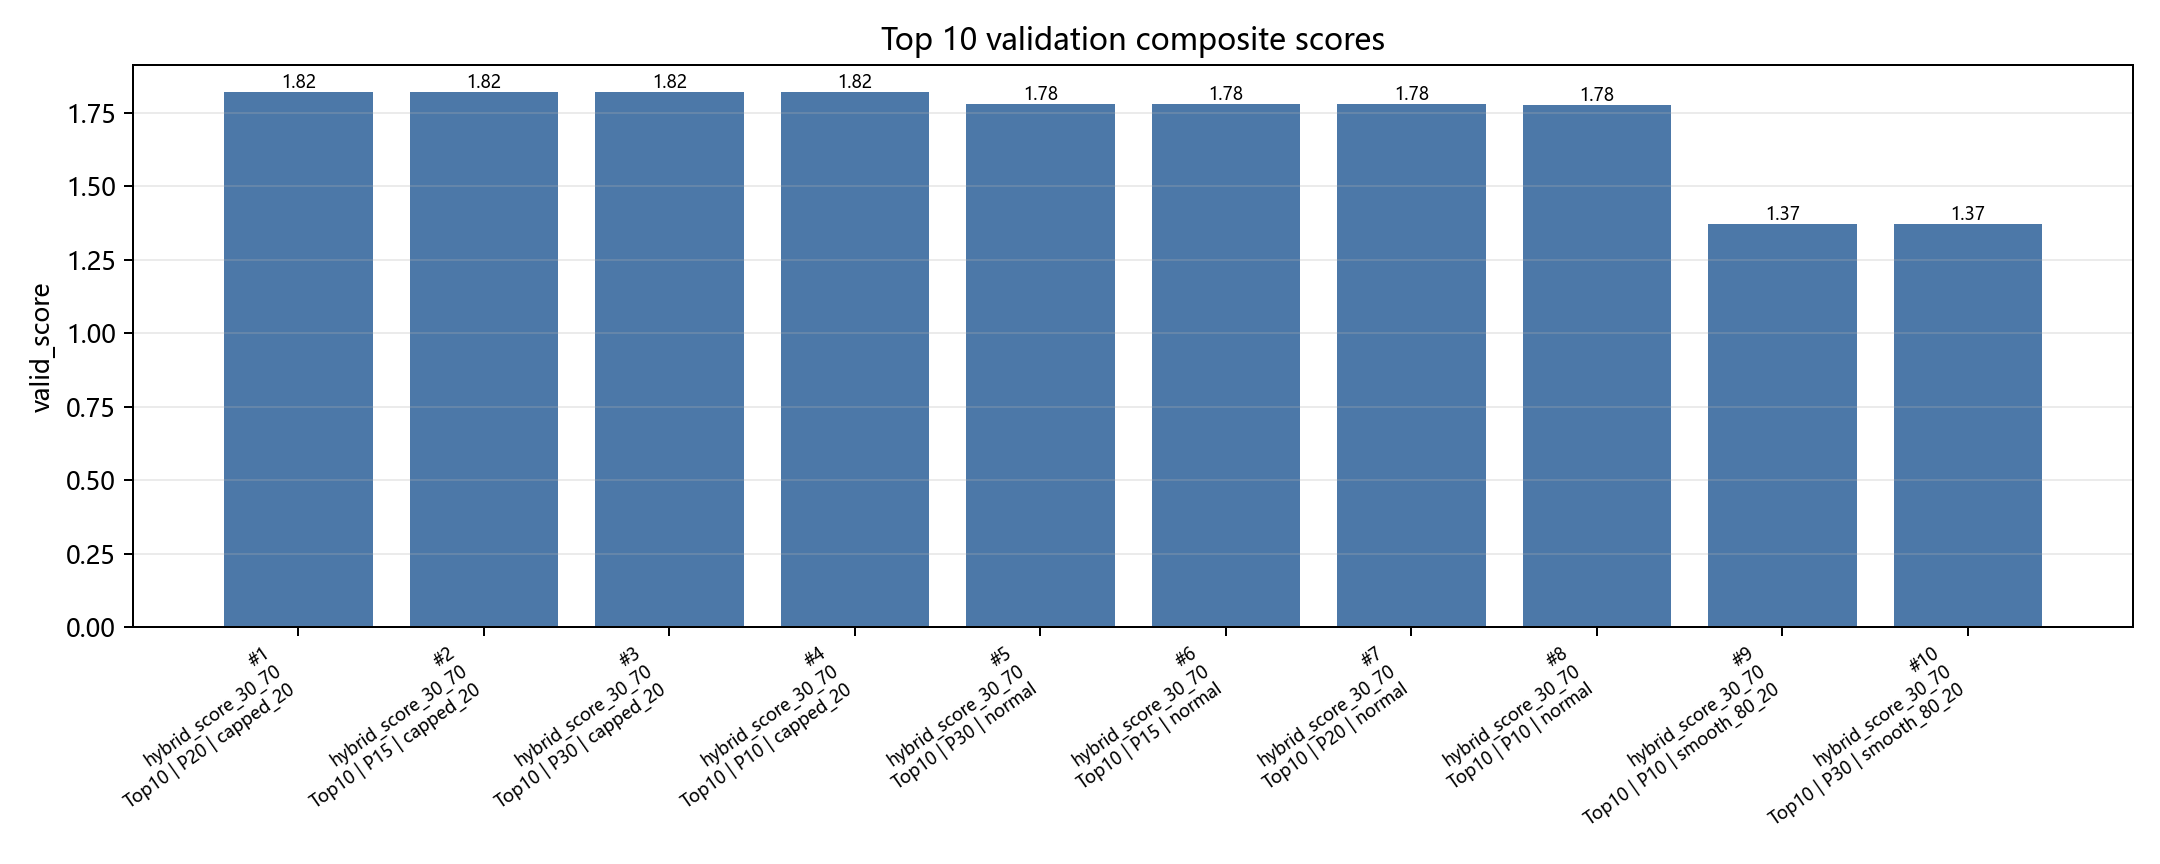

**这张图看什么：**  
这张图展示验证集综合评分最高的若干候选方案。综合评分不是只看收益，而是同时考虑 RankIC、Sharpe、年化收益、Alpha、最大回撤、换手率和评级区分度。

**结果怎么解释：**  
最终方案不是“测试集最高收益方案”，而是在验证集上综合表现较好的方案。这样做符合防止测试集调参的要求。

**需要注意：**  
如果某些候选方案在图上验证集分数很高，但测试集表现较弱，不能把它解释为未来一定有效。验证集只是参数选择依据，测试集才是最后检验。

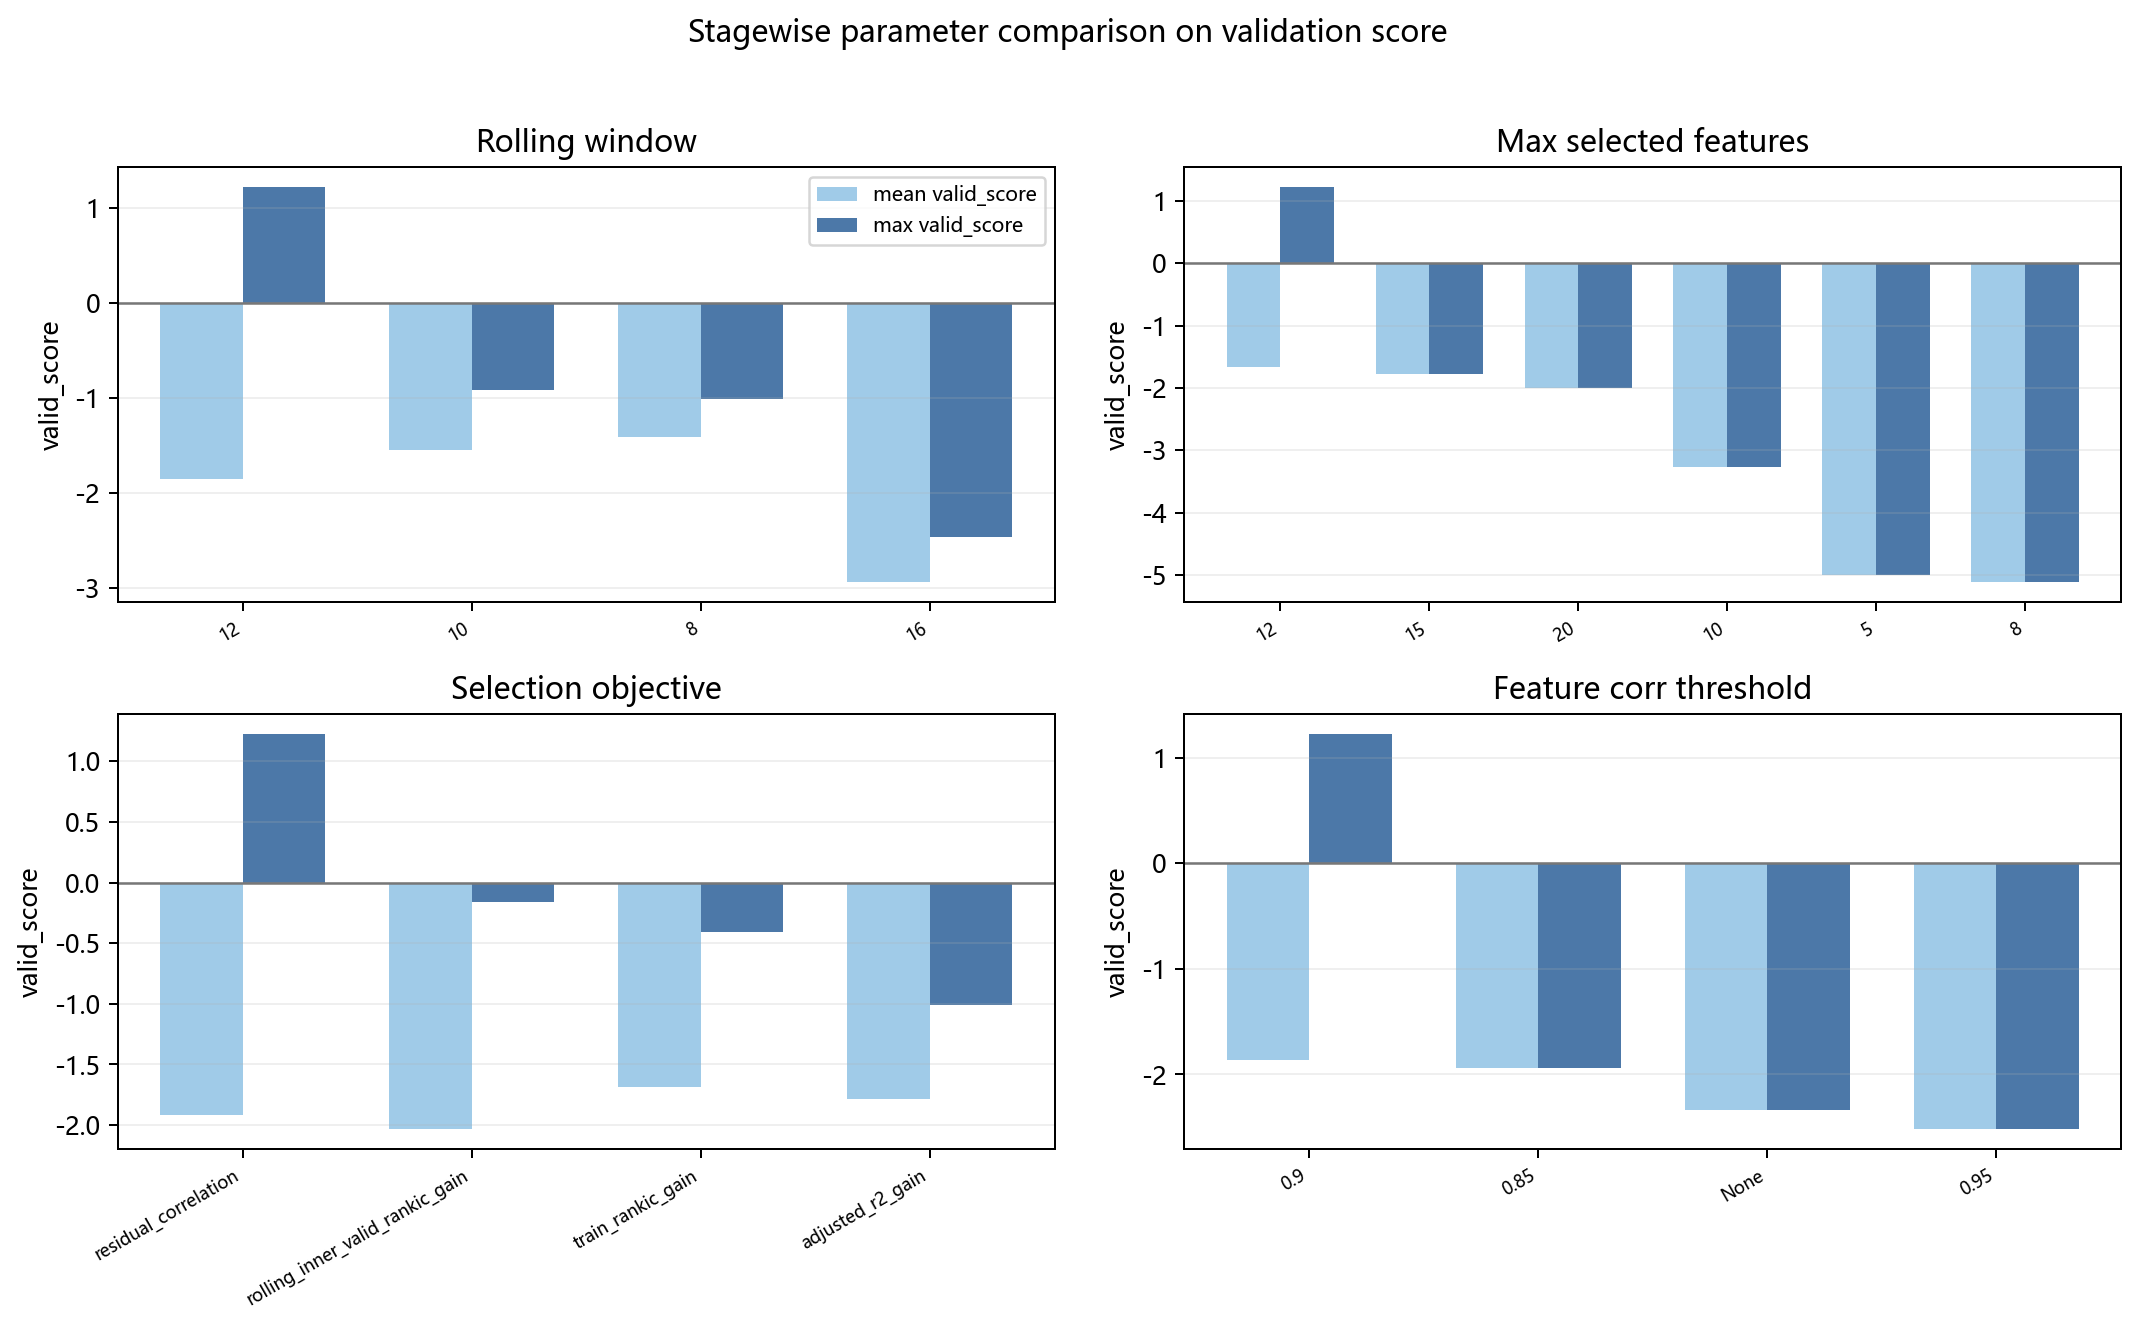

**这张图看什么：**  
这张图比较 rolling window、最大入选因子数、选择目标、回归重拟合方式等前向分步回归参数的验证集表现。

**结果怎么解释：**  
最终使用 `rolling_window=12`、`max_selected_features=12`、`selection_objective=residual_correlation`、`refit_method=OLS`。这说明在当前样本里，用过去 12 个季度滚动训练，并让模型每期选 12 个因子，是验证集上比较合适的复杂度。

**需要注意：**  
参数图只能说明“在当前验证集上更合适”，不能说明这些参数在所有市场环境下都最优。

### 21.2 不同评分方案对比图

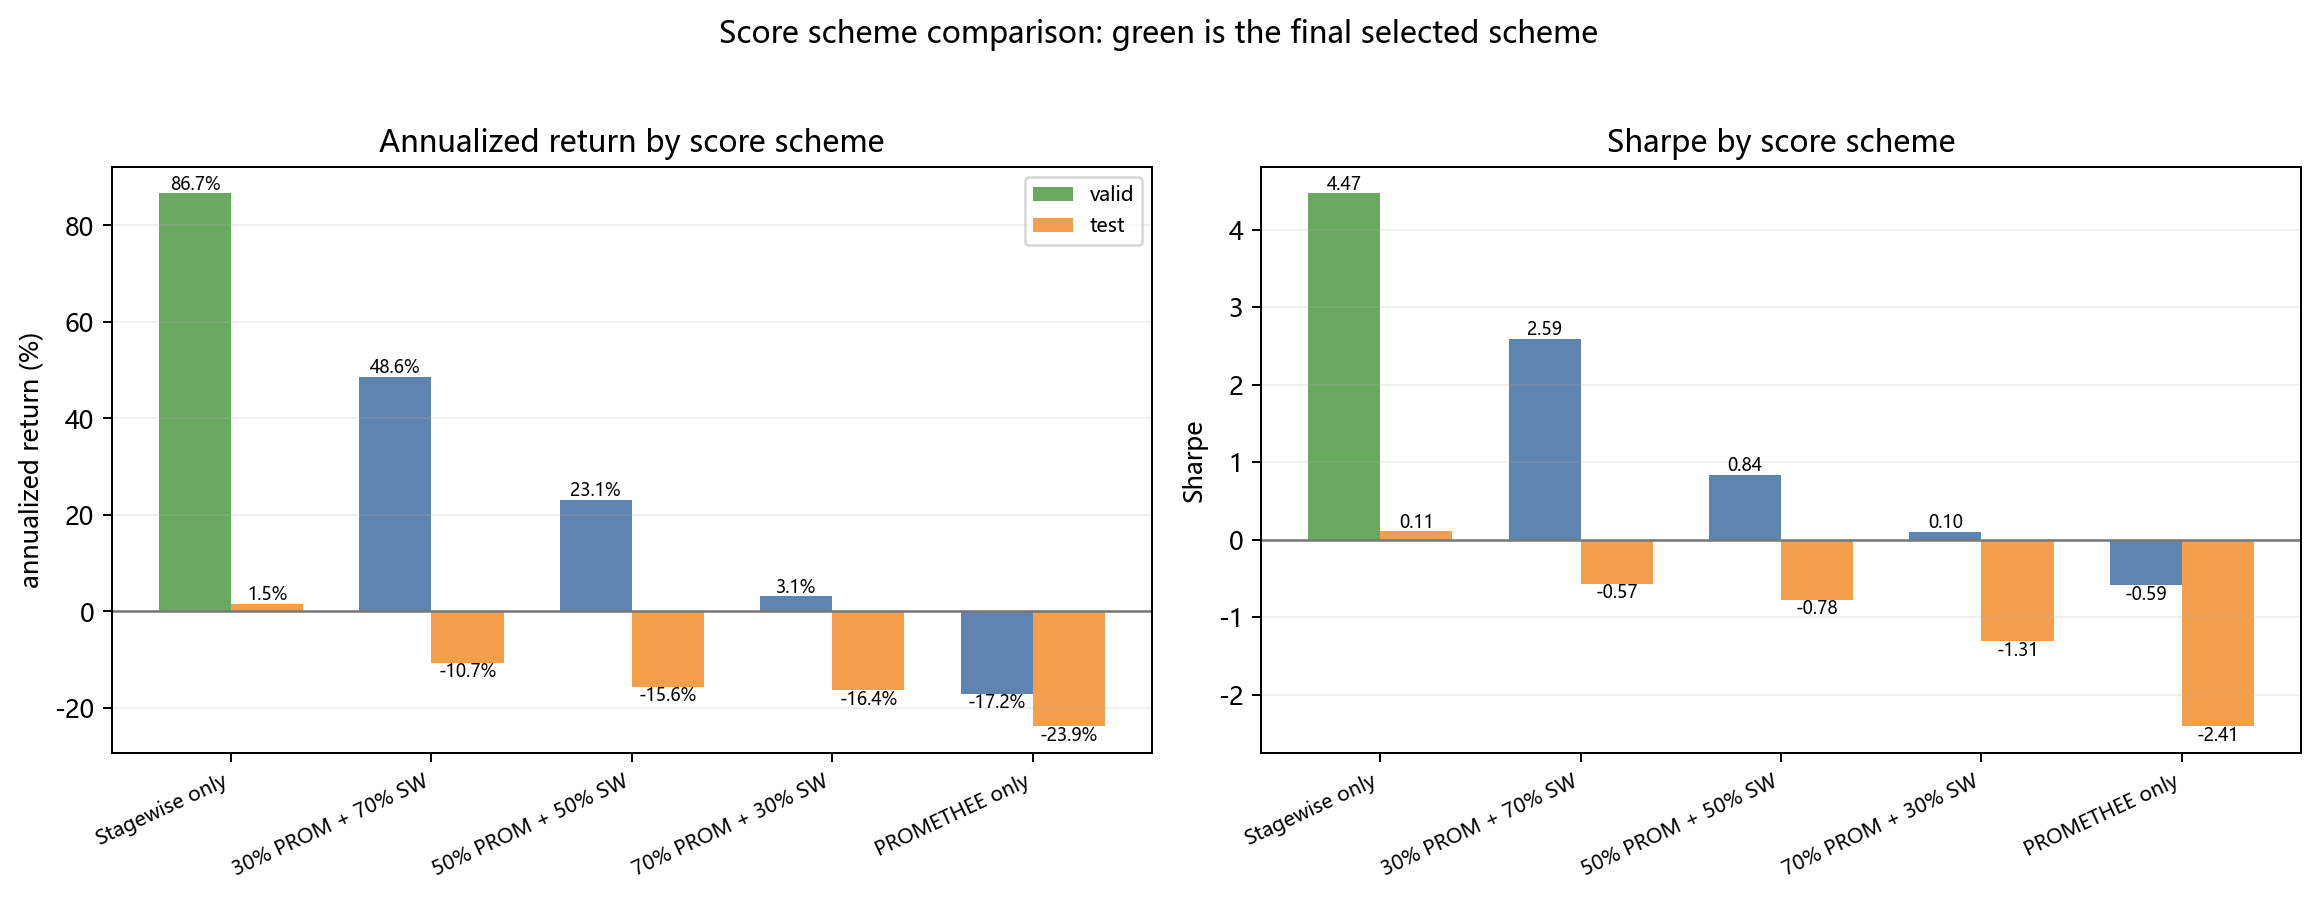

**这张图看什么：**  
这张图把 `pure_stagewise_score`、`pure_promethee_score`、`hybrid_score_70_30`、`hybrid_score_50_50`、`hybrid_score_30_70` 放在一起，对比 valid/test 的年化收益和 Sharpe。

**结果怎么解释：**  
图中最关键的信息是：最终主方案 `pure_stagewise_score` 在验证集上表现强，并且测试集没有严重崩溃。相比之下，PROMETHEE 或部分 Hybrid 方案在测试集上可能更弱，说明强行融合 PROMETHEE 不一定提高组合表现。

**需要注意：**  
这并不是说 PROMETHEE 没有价值。PROMETHEE 的价值更多在多属性解释和投资前景评价，而不是在本次样本中替代前向分步回归排序。

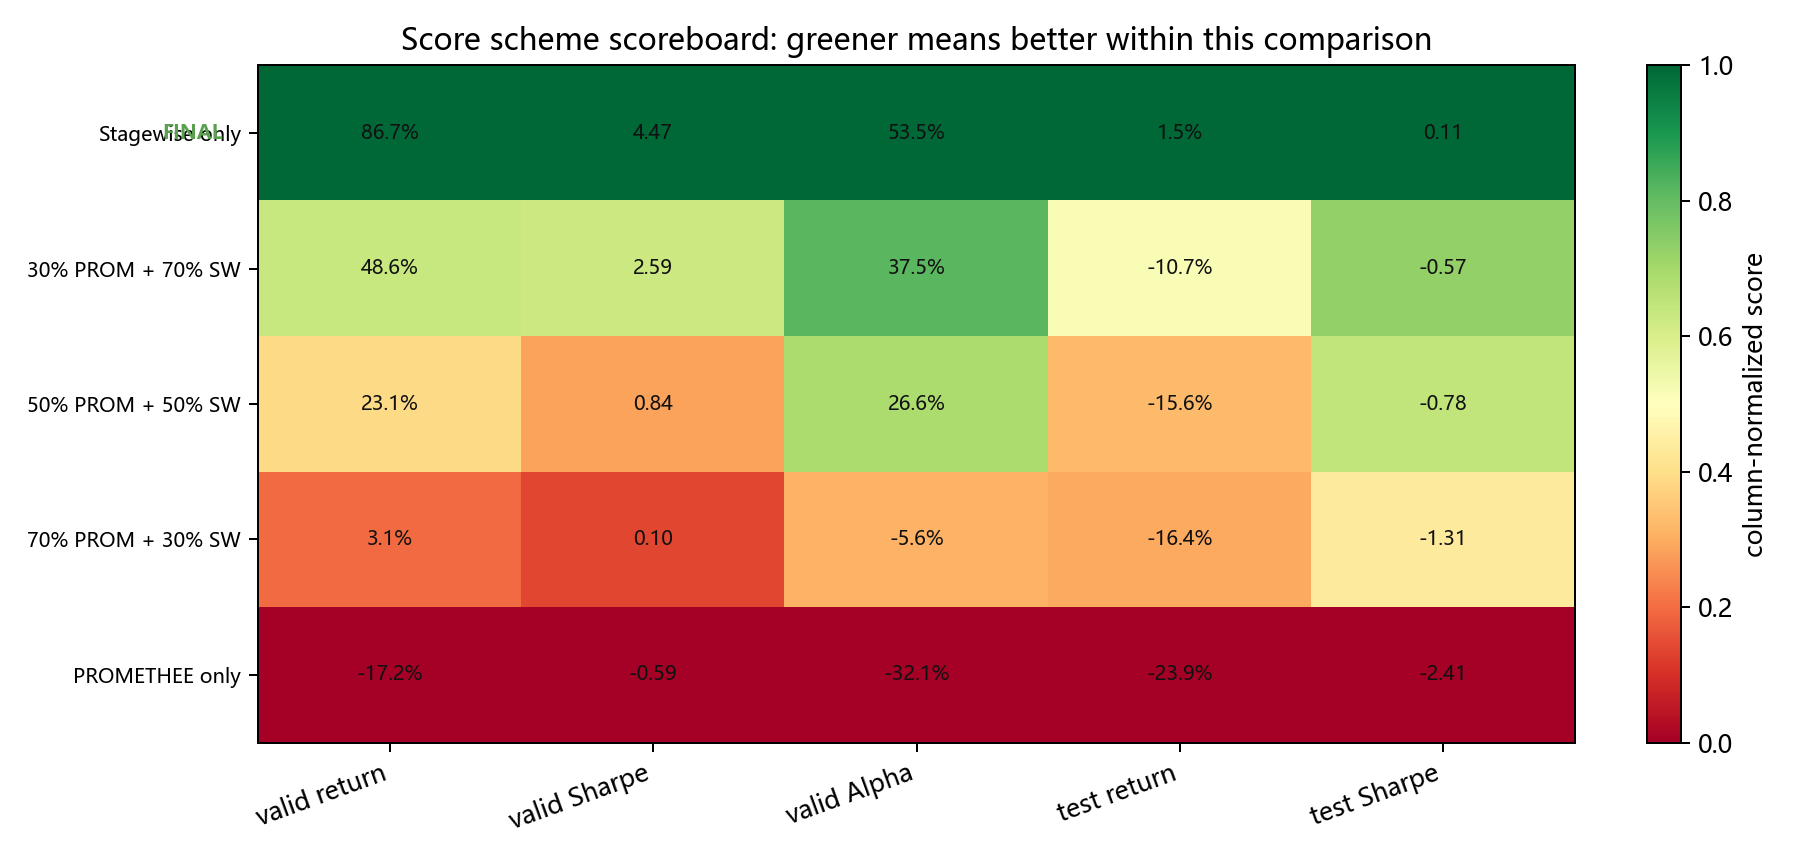

**这张图看什么：**  
这张图像成绩单一样，把每个评分方案的多个指标放在一起比较。颜色越明显，代表该方案在对应指标上越突出。

**结果怎么解释：**  
它让不同评分方案之间的强弱非常直观。最终方案不是只靠某一个指标取胜，而是在验证集收益、Sharpe、Alpha、测试集不崩溃和解释性之间比较平衡。

**需要注意：**  
成绩单颜色经过标准化处理，所以它展示的是相对强弱，不是原始收益数值。真实数值仍要看 `topk_performance_metrics_stagewise.csv` 和实验日志。

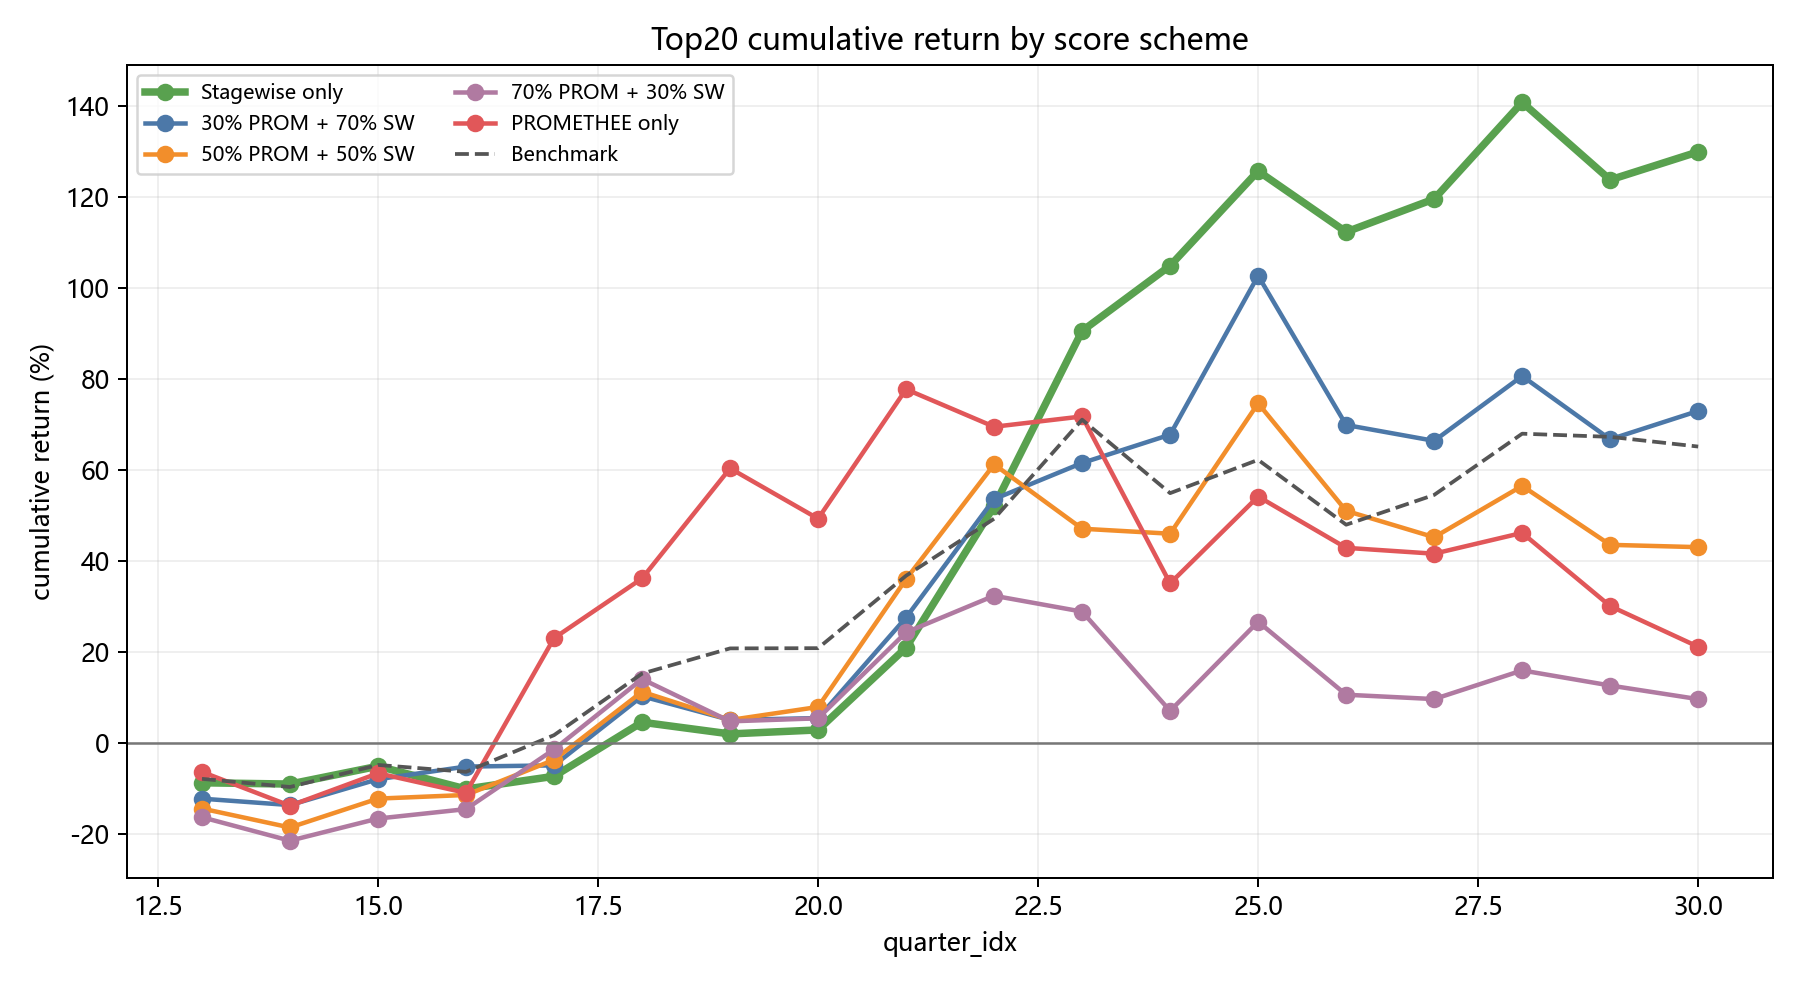

**这张图看什么：**  
这张图比较五种评分方案在 Top20 选股下的累计收益曲线，并与等权基准进行对比。

**结果怎么解释：**  
如果某条曲线长期高于其他曲线，说明该评分方案在样本期内的组合表现更好。最终方案曲线在验证集阶段优势更明显，但到测试期优势收窄。

**需要注意：**  
累计收益曲线容易让人产生“趋势会延续”的错觉。这里不能把历史曲线直接外推到未来，只能说明样本内和 holdout 测试中的表现。

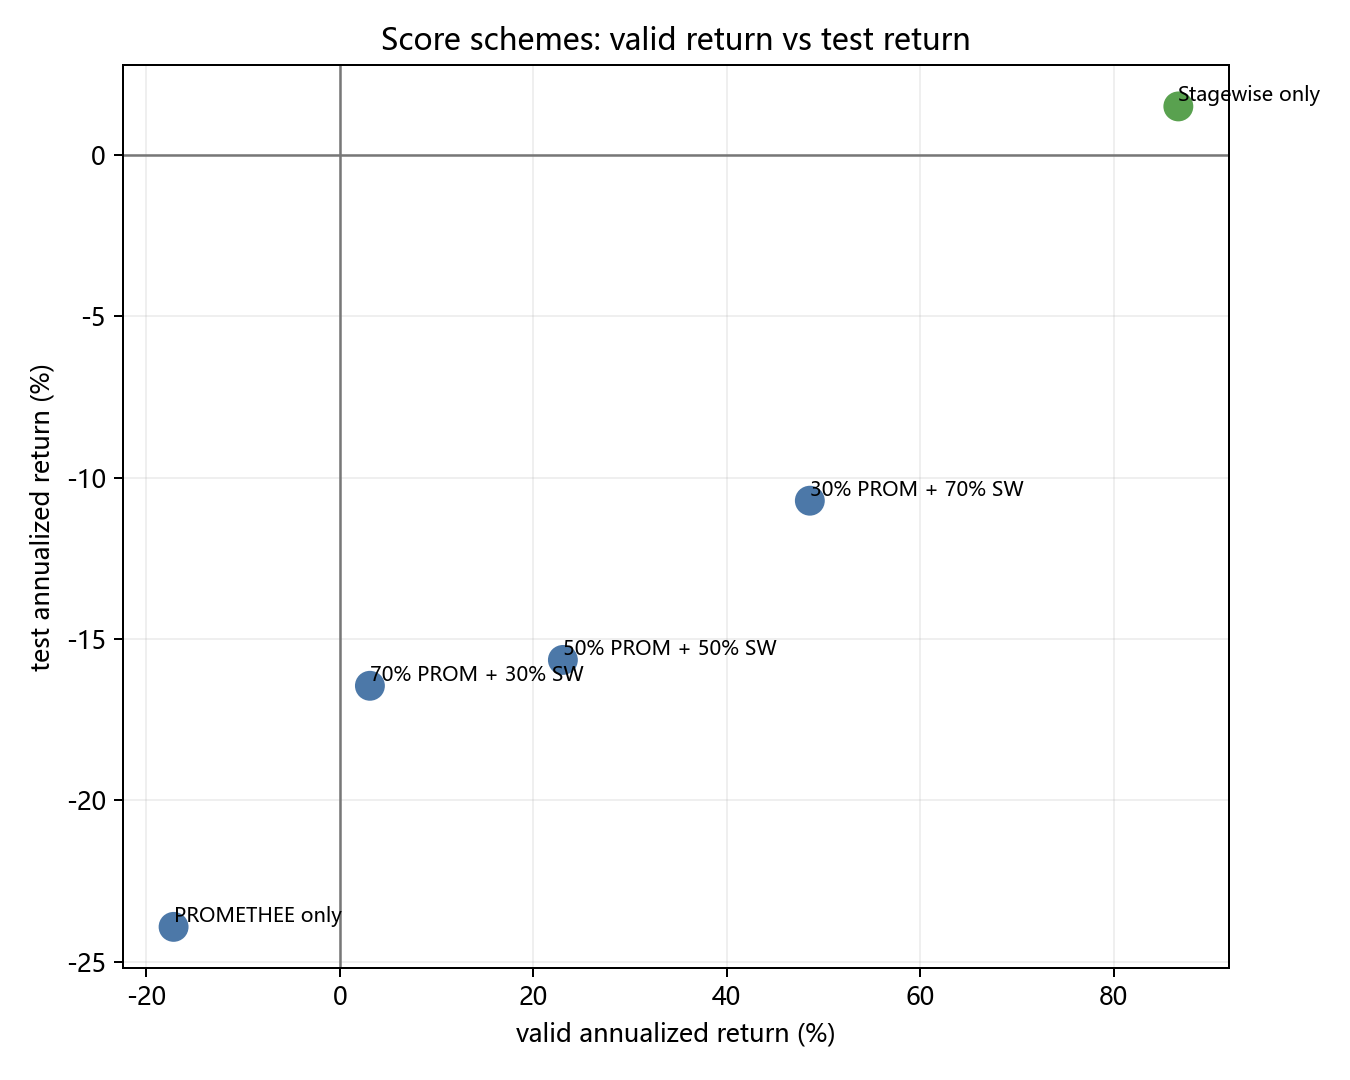

**这张图看什么：**  
横轴是验证集年化收益，纵轴是测试集年化收益。每个点代表一个评分方案。

**结果怎么解释：**  
理想方案应该在右上角，也就是验证集和测试集都较好。最终方案的意义在于：验证集表现好，测试集虽然明显回落，但没有变成严重负收益。

**需要注意：**  
如果一个方案测试集好但验证集差，不能选为最终主方案，因为那等于用测试集反向挑参数。

### 21.3 前向分步回归变量选择图

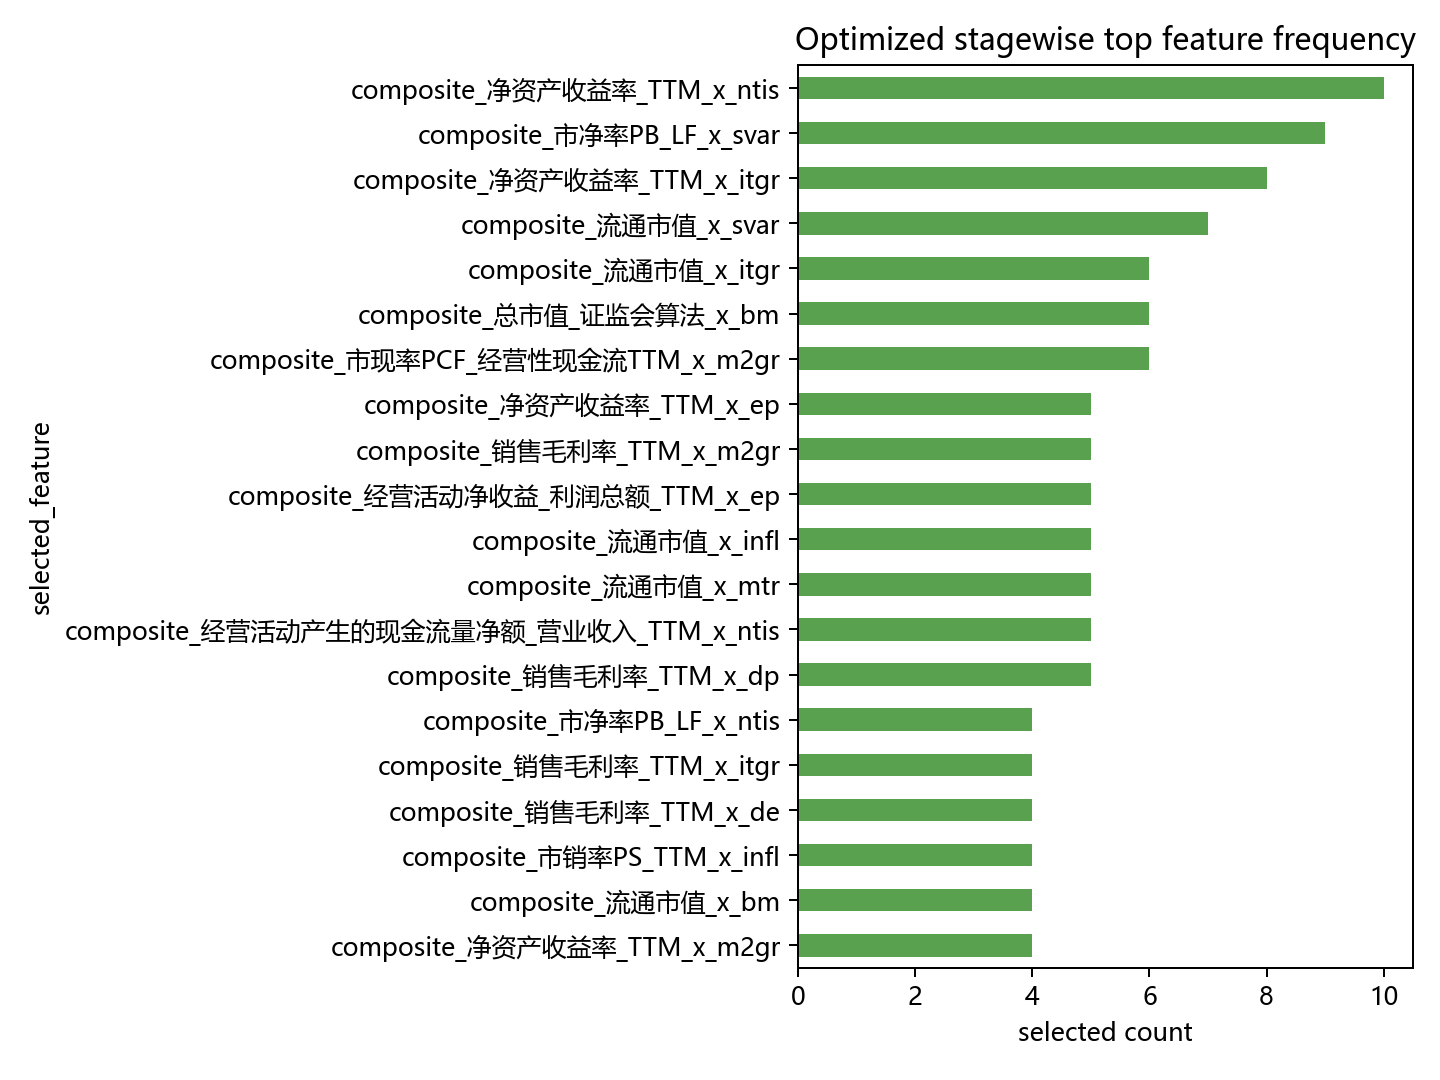

**这张图看什么：**  
这张图显示哪些综合因子在滚动窗口中被反复选中。入选次数越多，说明该因子越常被前向分步回归认为有解释价值。

**结果怎么解释：**  
高频因子集中在盈利能力、估值、市值规模与宏观变量的交互项上，说明模型不是随机挑因子，而是在不同窗口中反复捕捉某些财务特征与宏观环境的组合关系。

**需要注意：**  
因子入选频率高不等于因子未来一定有效，也不等于单个因子能稳定赚钱。它只说明该因子在历史滚动选择中经常被模型选到。

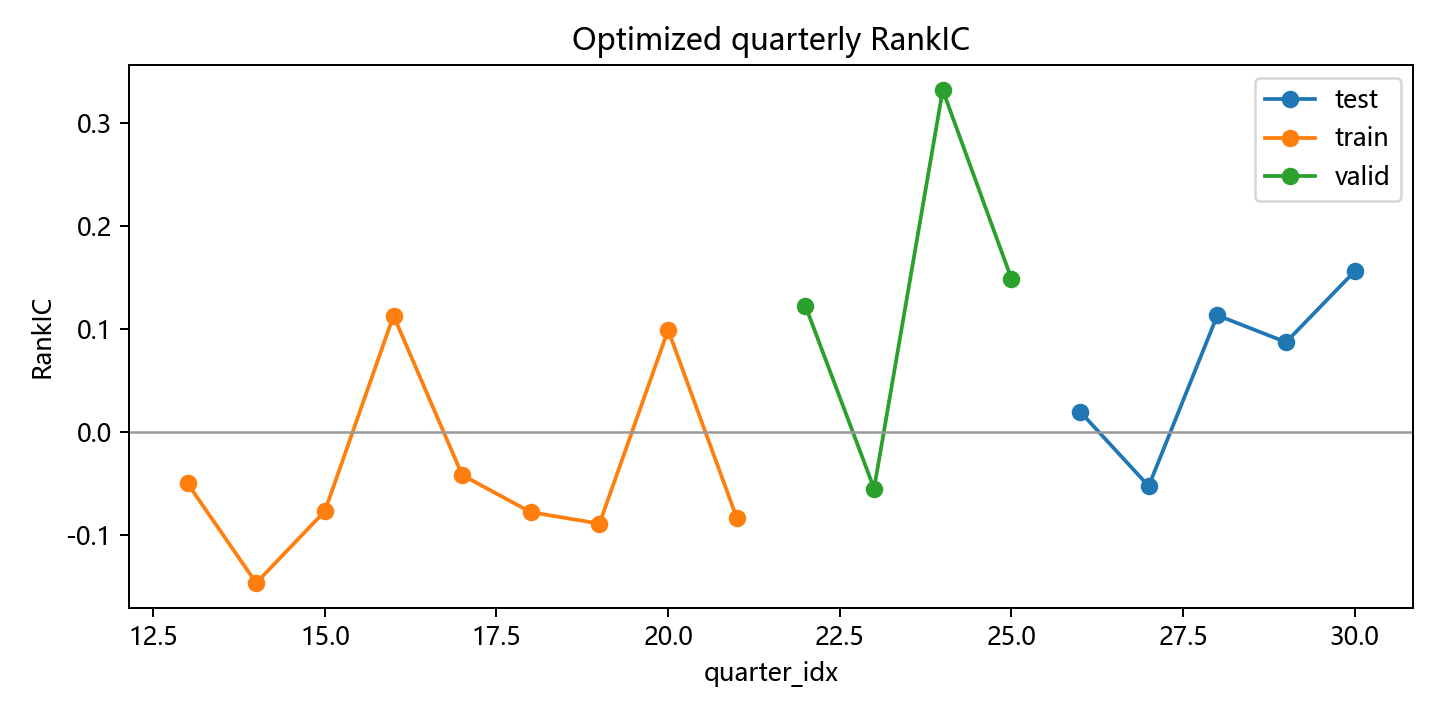

**这张图看什么：**  
这张图展示每个季度的 RankIC。RankIC 衡量模型排序和真实收益排序是否一致。

**结果怎么解释：**  
验证集和测试集的平均 RankIC 为正，说明模型有一定排序信号。但季度 RankIC 有正有负，说明信号并不稳定。

**需要注意：**  
RankIC 为正不等于模型能准确预测收益率。它只说明股票排序有一定参考价值。

### 21.4 PROMETHEE 图像结果

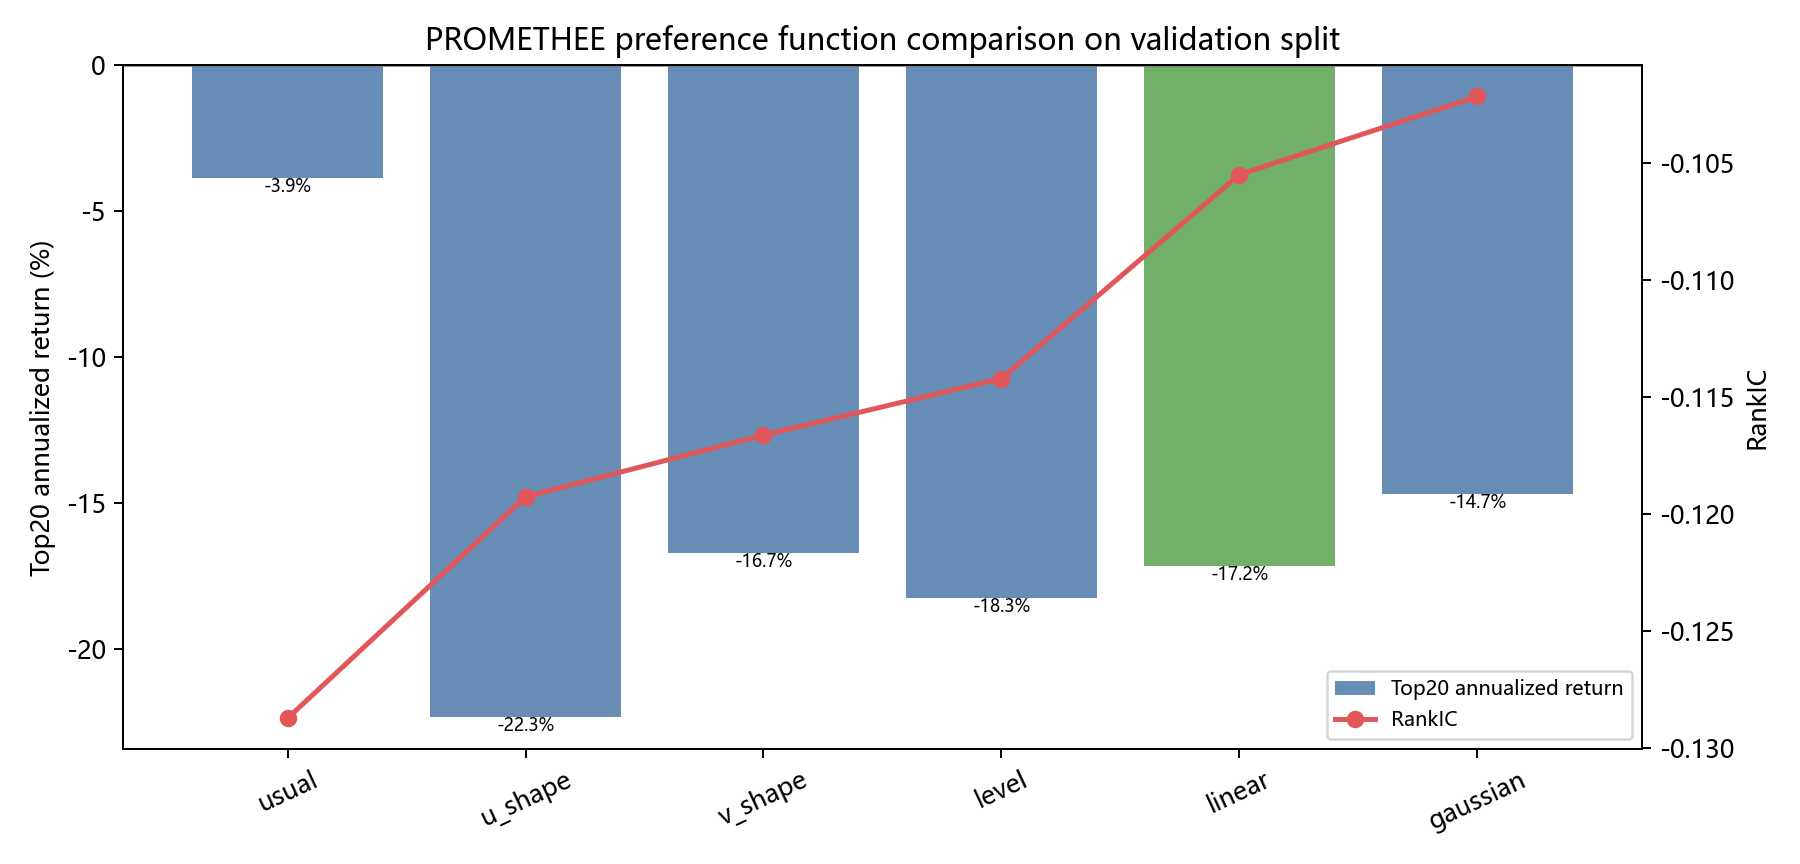

**这张图看什么：**  
这张图比较 `usual`、`u_shape`、`v_shape`、`level`、`linear`、`gaussian` 等 PROMETHEE 偏好函数的表现。

**结果怎么解释：**  
最终采用 `linear` 偏好函数，因为它对连续型标准化因子更合理：小差异给小优势，大差异才给强偏好。它比普通偏好函数更不容易放大极小差异。

**需要注意：**  
偏好函数比较是敏感性分析，不是用测试集挑最优函数。最终选择仍然服从验证集和方法解释性。

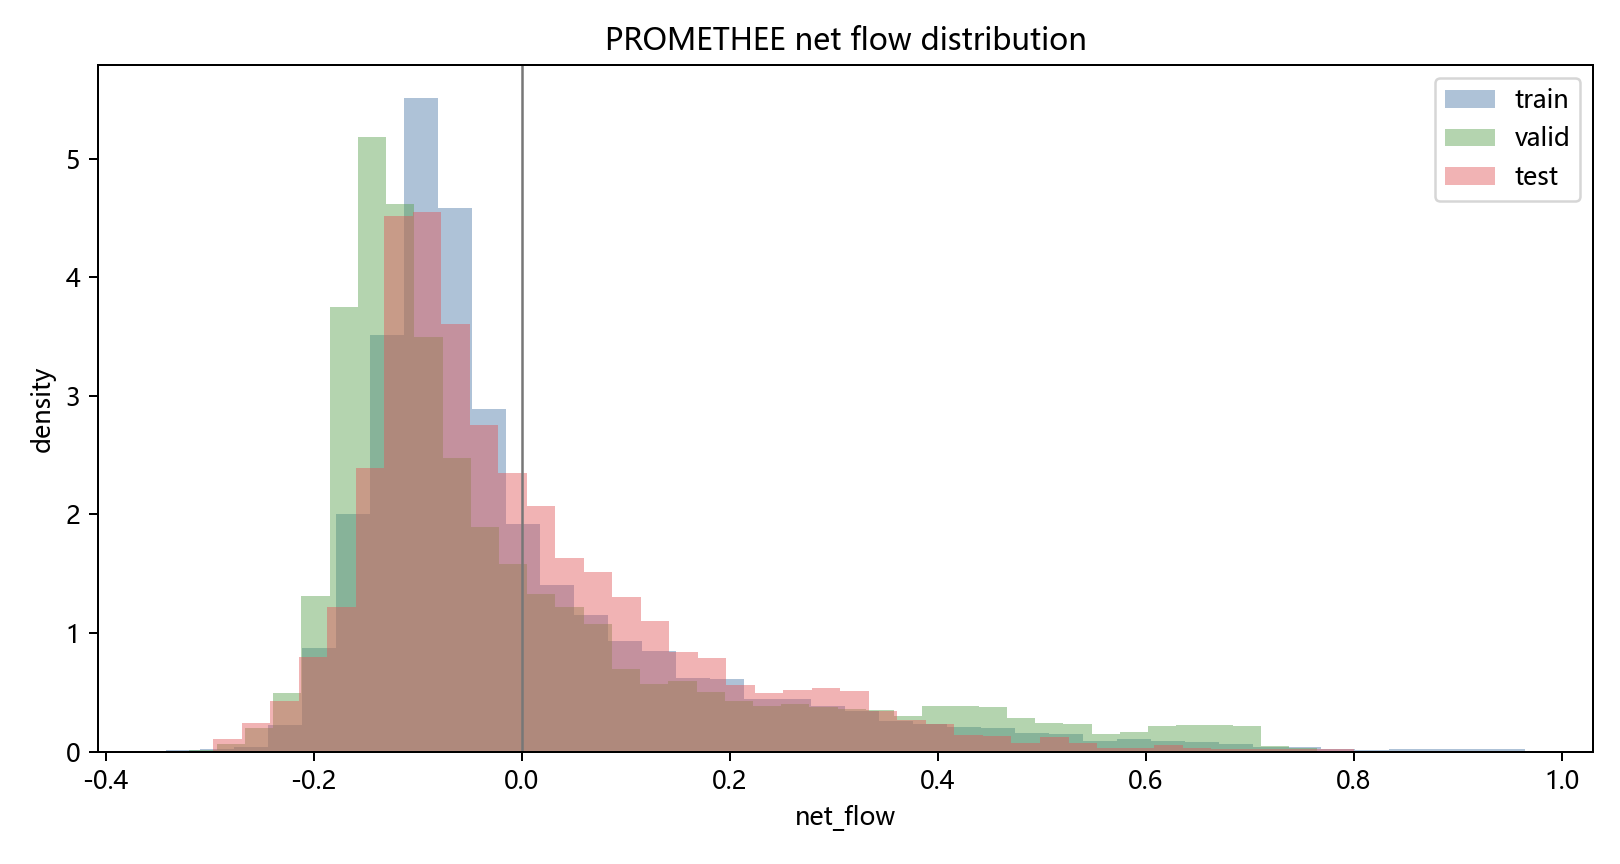

**这张图看什么：**  
这张图展示 PROMETHEE 净流 `net_flow` 的分布。净流越高，表示多属性综合评价下投资前景越好。

**结果怎么解释：**  
净流分布可以说明 PROMETHEE 是否把股票拉开了差距。如果所有股票挤在一起，说明评价区分度弱；如果有一定分散度，说明 PROMETHEE 有分层能力。

**需要注意：**  
PROMETHEE 净流是评价分数，不是未来收益率。净流高只能说明综合属性更优，不能保证下期收益更高。

### 21.5 Top-K 回测图像结果

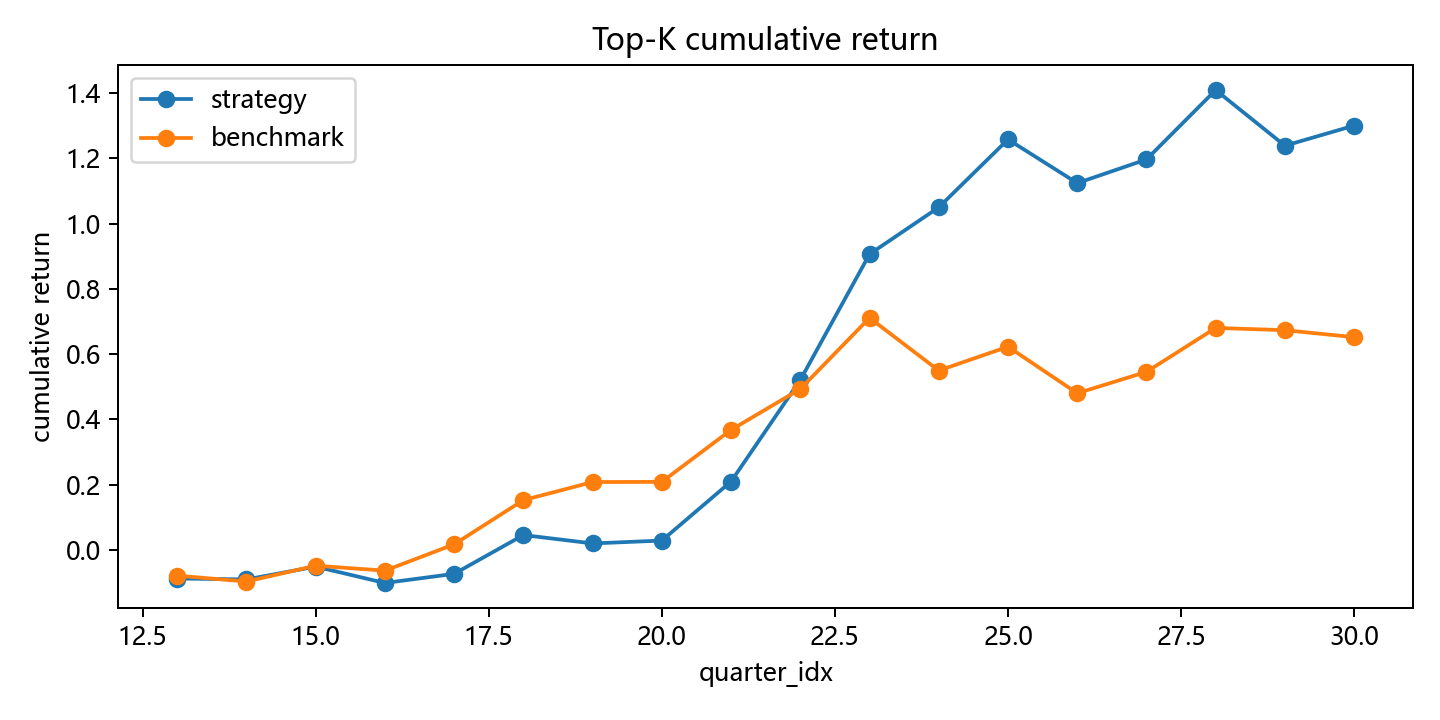

**这张图看什么：**  
这张图比较不同 Top-K 组合随时间变化的累计收益。

**结果怎么解释：**  
Top20 是最终主方案。它相比 Top10 更分散，相比 Top50 又不会过度稀释信号，因此更适合作为课程项目的主方案。

**需要注意：**  
累计收益曲线没有完全体现交易成本。由于最终方案换手率较高，真实投资中的收益可能低于图中无成本回测。

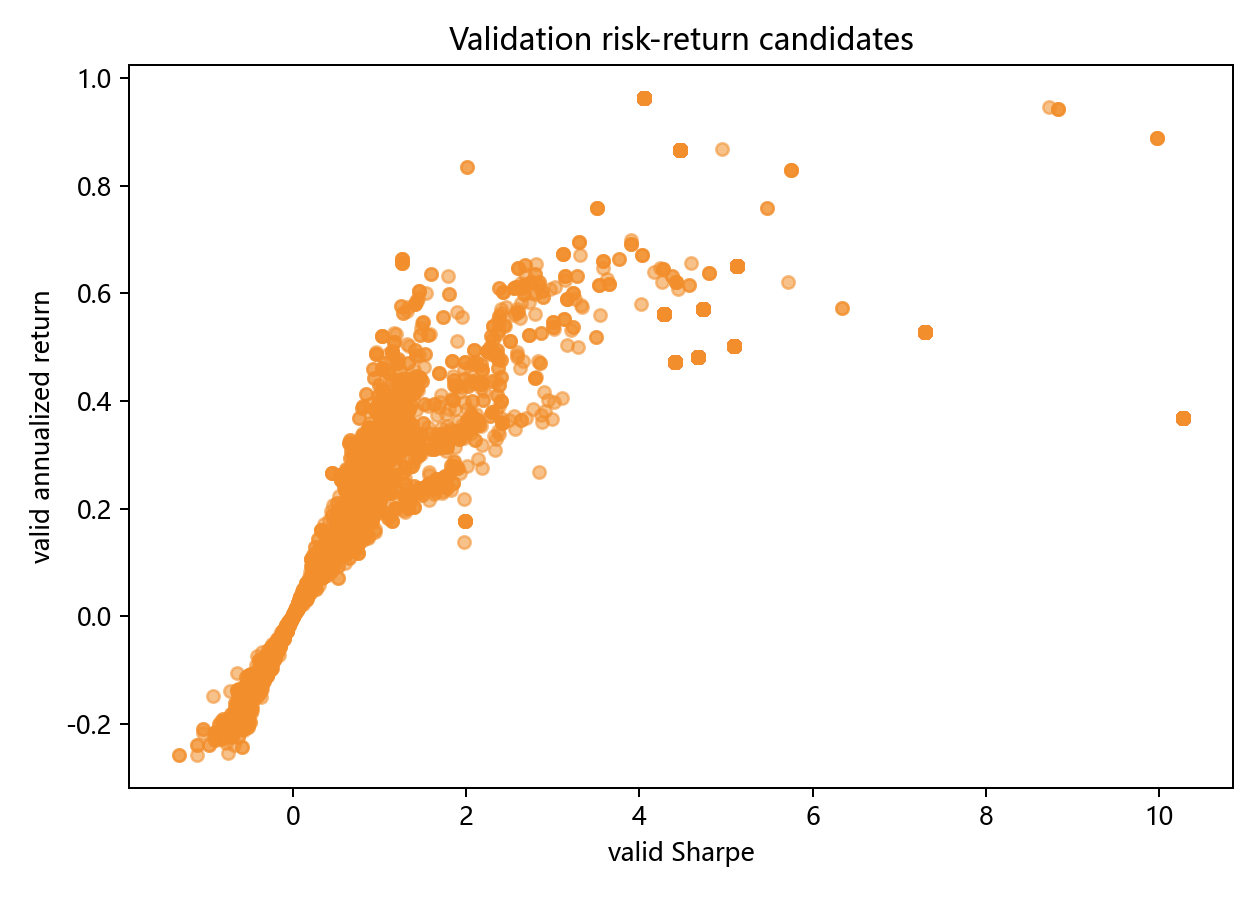

**这张图看什么：**  
横轴通常表示风险或波动率，纵轴表示收益。越靠左上方，一般代表收益更高、风险更低。

**结果怎么解释：**  
这张图帮助说明最终方案不是单纯追求最高收益，而是在收益和风险之间选择相对平衡的点。

**需要注意：**  
风险收益散点图是历史样本结果，不代表未来组合仍会处在同样位置。

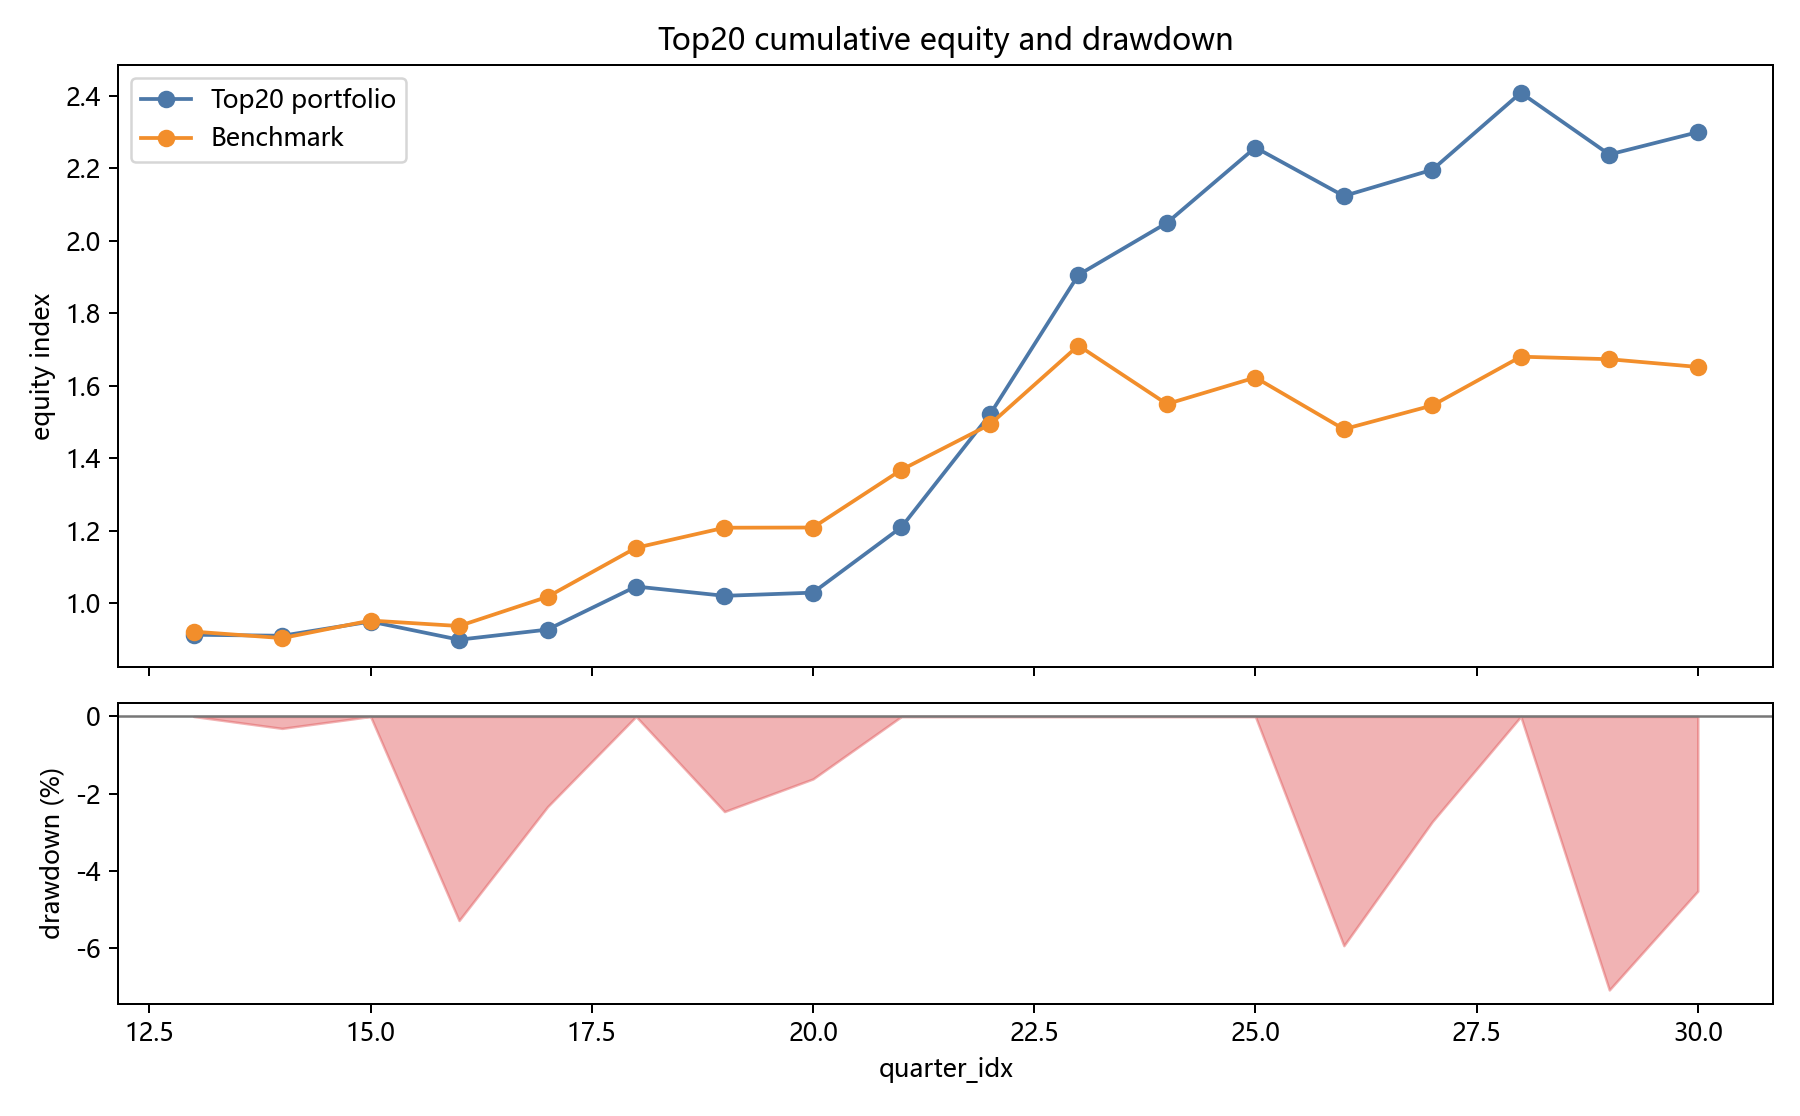

**这张图看什么：**  
这张图同时展示 Top20 组合净值曲线和回撤。净值看收益累积，回撤看从高点到低点的损失幅度。

**结果怎么解释：**  
测试期最大回撤约为 -7.08%，没有出现严重崩溃。但测试期收益也明显弱于验证集，说明样本外稳定性有限。

**需要注意：**  
回撤较小可能和测试期长度较短有关，不能据此断言未来风险一定低。

### 21.6 评级和分层图像结果

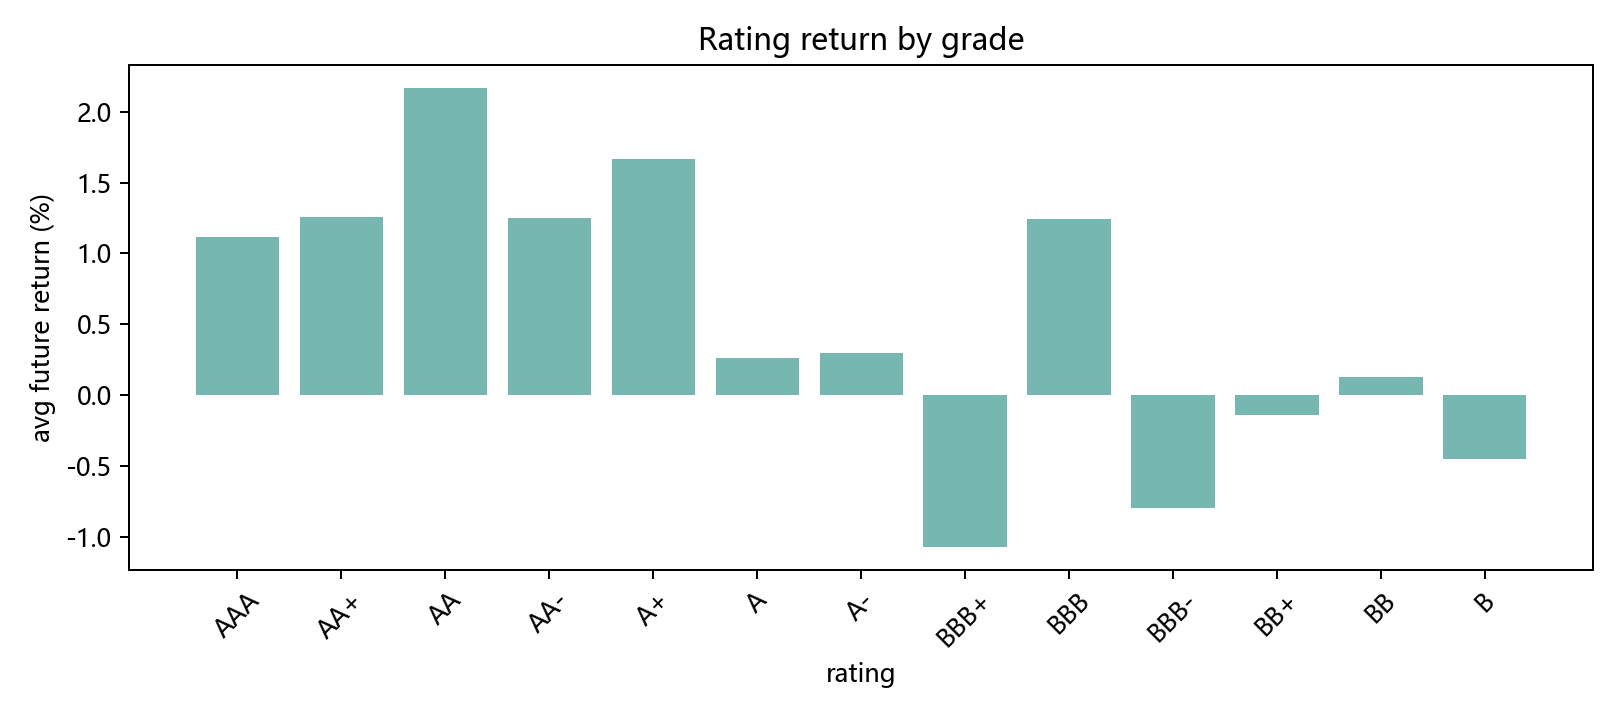

**这张图看什么：**  
这张图展示 AAA 到 B 各评级组的事后平均收益。

**结果怎么解释：**  
高评级组整体相对低评级组有一定优势，说明评级有候选池筛选价值。

**需要注意：**  
评级不是严格单调的。不能要求 AAA 一定高于 AA，AA 一定高于 A。股票未来收益噪声较大，评级只适合做分层参考。

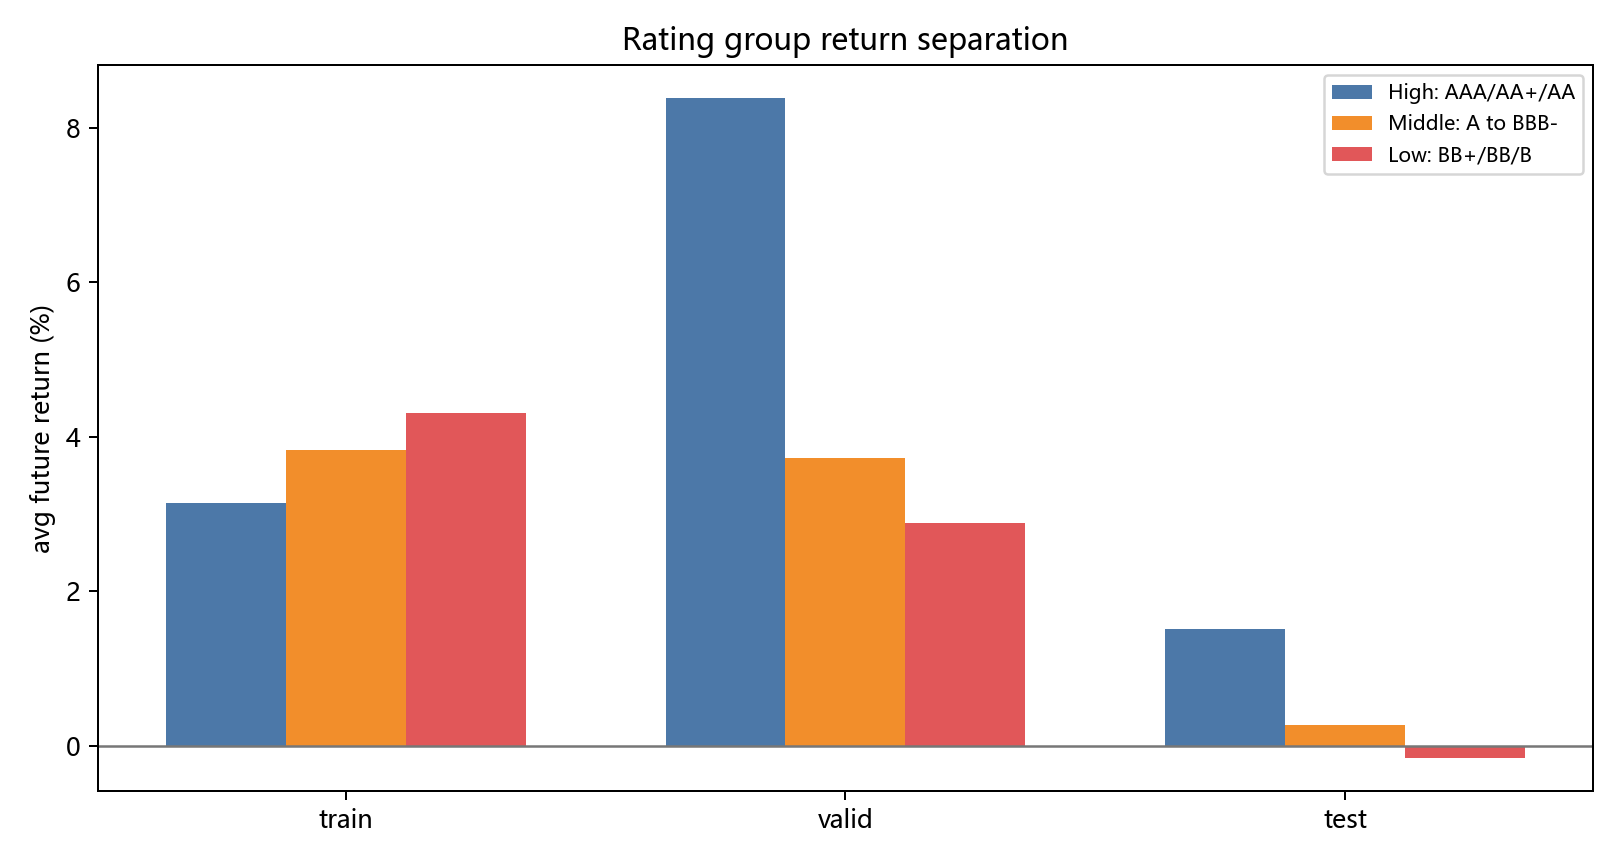

**这张图看什么：**  
这张图把 13 个评级合并成高、中、低三个组，对比不同 split 下的平均收益。

**结果怎么解释：**  
valid 和 test 中，高评级组相对低评级组表现更好，支持“评级具有一定筛选价值”的结论。

**需要注意：**  
train、valid、test 表现不完全一致，说明评级分层仍有样本期波动。

### 21.7 验证集与测试集稳定性图

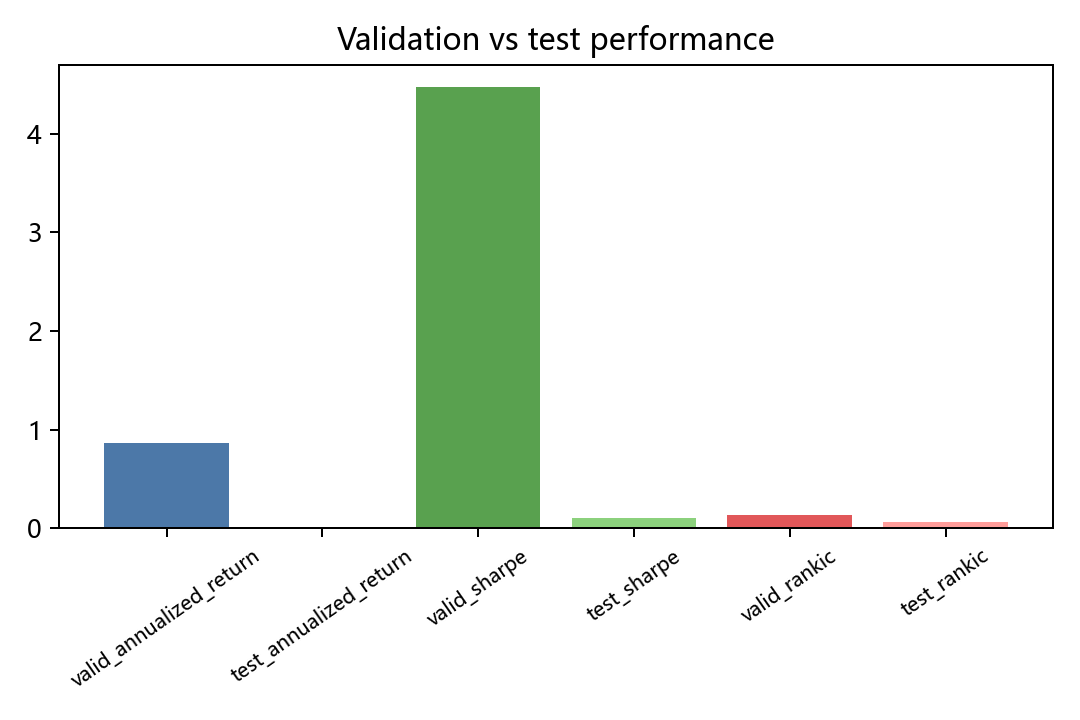

**这张图看什么：**  
这张图直接比较最终方案在 valid 和 test 上的核心指标。

**结果怎么解释：**  
验证集表现明显强于测试集。测试集仍有正收益和正 Sharpe，但数值很弱。这说明模型没有在 holdout 测试中完全失效，但也不能说稳定。

**需要注意：**  
这是报告中最需要谨慎解读的图。正确表述是“测试集未严重崩溃，但样本外稳定性有限”。

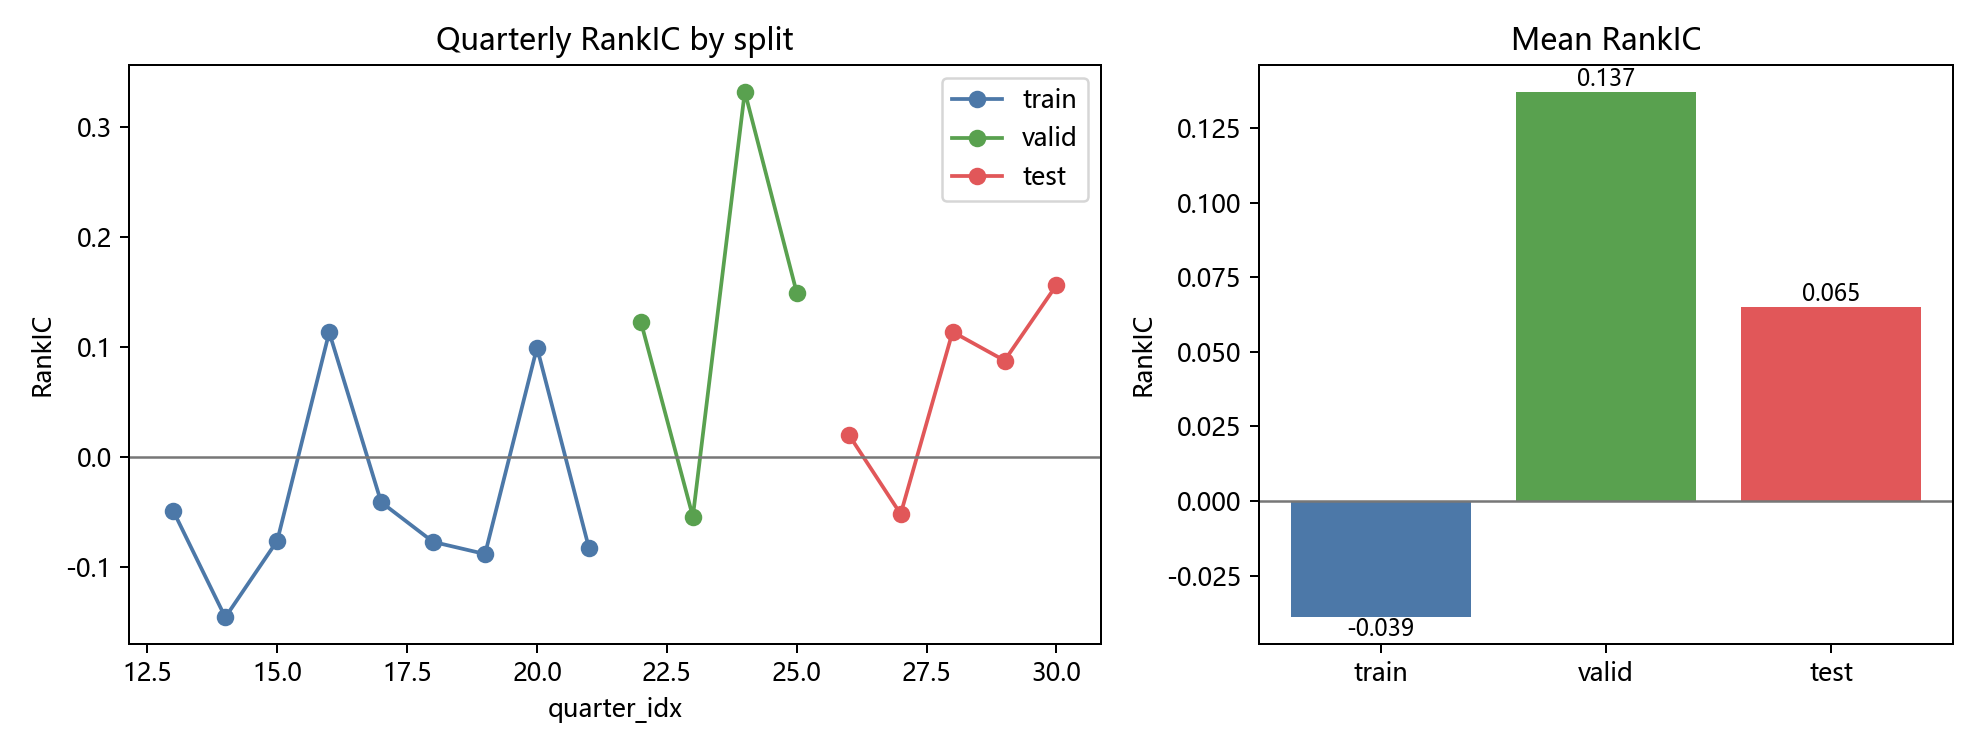

**这张图看什么：**  
这张图把季度 RankIC 和 train、valid、test 分区平均 RankIC 放在一起。

**结果怎么解释：**  
valid 和 test 平均 RankIC 为正，说明模型排序方向有一定参考价值；train 平均 RankIC 为负，说明模型并不是简单在训练集上强拟合。

**需要注意：**  
RankIC 是排序指标，不是收益率预测误差指标。弱正 RankIC 只能说明排序信号存在，不能说明模型能准确预测收益率。


## 22. 图像结果的总体结论

综合所有图像，可以得到四点稳妥结论：

1. 参数图说明最终方案来自验证集综合评分，而不是测试集挑选；
2. 评分方案对比图说明前向分步回归排序在本次样本中强于 PROMETHEE 和部分 Hybrid 方案；
3. Top-K 图说明 Top20 组合在验证集上表现较强，测试集未严重崩溃，但换手率较高；
4. 评级图说明高评级组整体有一定筛选价值，但评级收益不严格单调。

因此，这些图像支持的结论是：

> 当前模型是一个有一定排序能力和解释性的投资前景评价框架。

这些图像不支持的结论是：

> 当前模型可以准确预测未来收益率，或者可以作为稳定盈利策略直接使用。
